# A Anatomia do Sucesso na NBA: Analisando Perfis, Consistência e o Impacto de Trocas na Corrida aos Playoffs

**Disciplina**: Introdução a Ciência de Dados

**Professor**: Yuri de Almeida Malheiros Barbosa 

**Alunos**: Gabriel Sette de Figueirêdo (20250114544), Jocyneide Bernardo da Silva (20230103230) e Milton Bezerra Do Vale Filho (20250018898)

## 1. Introdução

A NBA moderna é marcada por um alto nível de competitividade e por constantes transformações táticas, nas quais o sucesso de uma equipe depende de múltiplos fatores interdependentes. Mais do que simplesmente vencer jogos, alcançar os playoffs e avançar nas fases finais exige consistência ao longo da temporada, um elenco bem estruturado e decisões estratégicas eficientes, como movimentações de trades.

Neste contexto, surge a necessidade de compreender quais elementos realmente influenciam o desempenho das equipes. Este trabalho tem como objetivo investigar a anatomia do sucesso na NBA, analisando como a consistência das equipes, os perfis dos jogadores e o impacto das trades contribuem para a probabilidade de classificação aos playoffs e para o desempenho em fases decisivas.

Para atingir esse objetivo, estruturamos a análise a partir das seguintes questões: (i) verificar se equipes classificadas apresentam melhor início, maior consistência ou evolução ao longo da temporada; (ii) identificar perfis de jogadores com base em métricas estatísticas e analisar sua distribuição em relação às posições tradicionais; (iii) avaliar como a composição desses perfis influencia o desempenho coletivo e a classificação; (iv) investigar se trades realizadas durante a temporada geram melhora significativa de performance; e (v) quantificar o impacto dessas movimentações em termos de probabilidade de classificação e avanço nos playoffs.

A abordagem adotada combina técnicas de análise exploratória de dados, clusterização e modelagem probabilística, permitindo uma visão abrangente e quantitativa sobre os fatores que contribuem para o sucesso na liga. Dessa forma, este trabalho busca não apenas identificar padrões, mas também fornecer insights sobre como equipes podem otimizar sua construção e suas decisões ao longo da temporada.

## 2. Times que chegam aos playoffs apresentam melhor desempenho no início, maior consistência ou maior evolução ao longo da temporada ?

### 2.1 Introdução

O desempenho de uma equipe na NBA não é estático ao longo da temporada, podendo variar em função de fatores como entrosamento, desempenho individual dos jogadores, lesões e ajustes táticos. Dessa forma, compreender como os times evoluem ao longo dos jogos é fundamental para identificar padrões associados ao sucesso esportivo.

Neste contexto, surge a seguinte questão de pesquisa: times que alcançam os playoffs apresentam melhor desempenho desde o início da temporada, maior consistência ao longo dos jogos ou uma evolução significativa com o passar do tempo? Para investigar essa questão, a temporada foi segmentada em três partes: início, meio e fim. Nós consideramos o primeiro terço dos jogos como representação do desempenho inicial das equipes.

A partir dessa divisão, são analisadas métricas como taxa de vitórias em diferentes períodos, variação de desempenho ao longo da temporada e níveis de consistência, permitindo comparar equipes bem-sucedidas e não bem-sucedidas.

### 2.2 Dados Utilizados

* **`TeamGames`**: Contém o registro detalhado, jogo a jogo, do desempenho das equipes, o que nos permite calcular a taxa de vitória no início e no fim da temporada, além de medir a consistência.
* **`TeamSeasonOutcomes`**: Consolida os resultados finais de cada equipe na liga, servindo como nossa variável alvo (indicando se o time alcançou ou não os playoffs).

**Recorte Temporal (A partir de 2000):**
Optamos por restringir nossa análise exclusivamente às temporadas a partir do ano 2000. Essa delimitação temporal foi implementada para garantir a integridade da análise, devido a diferenças estruturais significativas nas tabelas ao longo do tempo. Isso se aplica a todas as tabelas (se não houve mudança na própria tabela, foi aplicado um filtro).

Para mais informações sobre colunas, tipos de dado entre outras, consultar [ColetaDeDados.MD](./coletaDosDados.MD)

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 2.3 Pré-Processamento

In [44]:
TeamGames = pd.read_csv(
    "TeamGames.csv",
    engine="python",
    on_bad_lines="skip"
)

TeamGames = TeamGames.loc[:, ~TeamGames.columns.str.contains("Unnamed")] #remoção de colunas "fantasmas"

#garantindo tipo de dado
TeamGames["Date"] = pd.to_datetime(TeamGames["Date"], errors="coerce")
TeamGames["Tm"] = pd.to_numeric(TeamGames["Tm"], errors="coerce")
TeamGames["Opp"] = pd.to_numeric(TeamGames["Opp"], errors="coerce")
TeamGames["season"] = pd.to_numeric(TeamGames["season"], errors="coerce")

#útil para a aplicação de filtro posterior
TeamGames["is_playoff"] = TeamGames["is_playoff"].isin([True, 'True', 'true', 1, '1'])
TeamGames["team"] = TeamGames["team"].astype(str).str.strip()
TeamGames = TeamGames.dropna(subset=["Date", "team", "Tm", "Opp", "season"])

TeamSeasonOutcomes = pd.read_csv("team_season_outcomes.csv")

playoffs = TeamSeasonOutcomes[["team", "season", "reached_playoffs"]].copy() #só vamos usar essas colunas

#renomear + garantindo tipos
playoffs = playoffs.rename(columns={"reached_playoffs": "Playoff"})
playoffs["Playoff"] = playoffs["Playoff"].astype(int)
playoffs["season"] = pd.to_numeric(playoffs["season"], errors="coerce")
playoffs["team"] = playoffs["team"].astype(str).str.strip()

#filtro + cálculo de vitórias
df_regular = TeamGames[~TeamGames["is_playoff"]].copy()
df_regular["Win"] = (df_regular["Tm"] > df_regular["Opp"]).astype(int)

#ordenação
df_regular = df_regular.sort_values(by=["team", "season", "Date"])
df_regular["Game_Number"] = df_regular.groupby(["team", "season"]).cumcount() + 1

#criação dos períodos a serem analisados
df_regular["Season_Phase"] = df_regular.groupby(["team", "season"])["Game_Number"].transform(
    lambda x: pd.cut(
        x,
        bins=[0, x.max()/3, 2*x.max()/3, x.max()],
        labels=["Início", "Meio", "Fim"]
    )
)

print(f"Shape de df_regular: {df_regular.shape}")
df_regular.head(n=3)

Shape de df_regular: (62488, 18)


,G,Date,Opponent,Tm,Opp,W,L,Streak,Attend.,LOG,Notes,is_playoff,team,season,Start (ET),Win,Game_Number,Season_Phase
0,1,1999-11-02,Washington Wizards,87,94,0,1,L 1,16038.0,NaN,NaN,False,ATL,2000,NaN,0,1,Início
1,2,1999-11-04,Milwaukee Bucks,109,119,0,2,L 2,18514.0,NaN,NaN,False,ATL,2000,NaN,0,2,Início
2,3,1999-11-06,Chicago Bulls,113,97,1,2,W 1,13342.0,NaN,NaN,False,ATL,2000,NaN,1,3,Início


### 2.4 Feature Engineering

In [45]:
#feature engineering

#fazemos a média de Win e dividimos em colunas
phase_performance = df_regular.groupby(["team", "season", "Season_Phase"])["Win"].mean().unstack()
phase_performance.columns = ["Win_Inicio", "Win_Meio", "Win_Fim"]

#criação do conceito de evolução, evolução é Win_final - Win_inicial
phase_performance["Evolucao"] = phase_performance["Win_Fim"] - phase_performance["Win_Inicio"]

#criação do conceito de consistencia, consistencia é o desvio padrao
phase_performance["Consistencia"] = phase_performance[["Win_Inicio", "Win_Meio", "Win_Fim"]].std(axis=1)

#juntámos com nosso target
phase_performance = phase_performance.reset_index()
team_analysis = phase_performance.merge(
    playoffs,
    on=["team", "season"],
    how="inner"
)

team_analysis = team_analysis.dropna()

print(f"Tamanho da base final para os gráficos: {team_analysis.shape}")
team_analysis.head()

Tamanho da base final para os gráficos: (771, 8)


C:\Users\gsett\AppData\Local\Temp\ipykernel_19872\246818646.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phase_performance = df_regular.groupby(["team", "season", "Season_Phase"])["Win"].mean().unstack()


,team,season,Win_Inicio,Win_Meio,Win_Fim,Evolucao,Consistencia,Playoff
0,ATL,2000,0.407407,0.407407,0.214286,-0.193122,0.111499,0
1,ATL,2001,0.333333,0.333333,0.250000,-0.083333,0.048113,0
2,ATL,2002,0.370370,0.333333,0.500000,0.129630,0.087515,0
3,ATL,2003,0.407407,0.333333,0.535714,0.128307,0.102394,0
4,ATL,2004,0.259259,0.407407,0.357143,0.097884,0.075339,0


### 2.5 Análises Realizadas

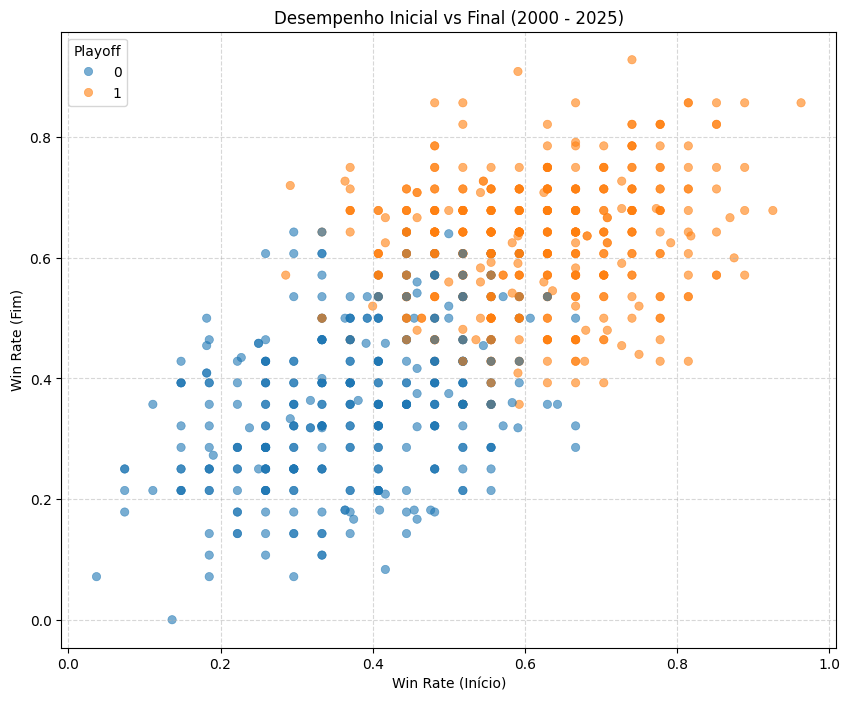

In [46]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    data=team_analysis,
    x="Win_Inicio",
    y="Win_Fim",
    hue="Playoff",
    alpha=0.6,
    edgecolor=None
)

plt.title("Desempenho Inicial vs Final (2000 - 2025)")
plt.xlabel("Win Rate (Início)")
plt.ylabel("Win Rate (Fim)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Análise:

O gráfico revela que a classificação exige consistência, com os times de playoff fortemente agrupados no quadrante superior direito.
A fronteira entre eliminação e sucesso fica muito evidente perto da marca de 0.50 (50% de aproveitamento) em ambas as fases da temporada.
Além disso, a forte tendência diagonal demonstra que arrancadas milagrosas são raras, pois quem começa muito mal dificilmente se recupera.
Seria interessante em um trabalho futuro criar um modelo de árvore de decisão.

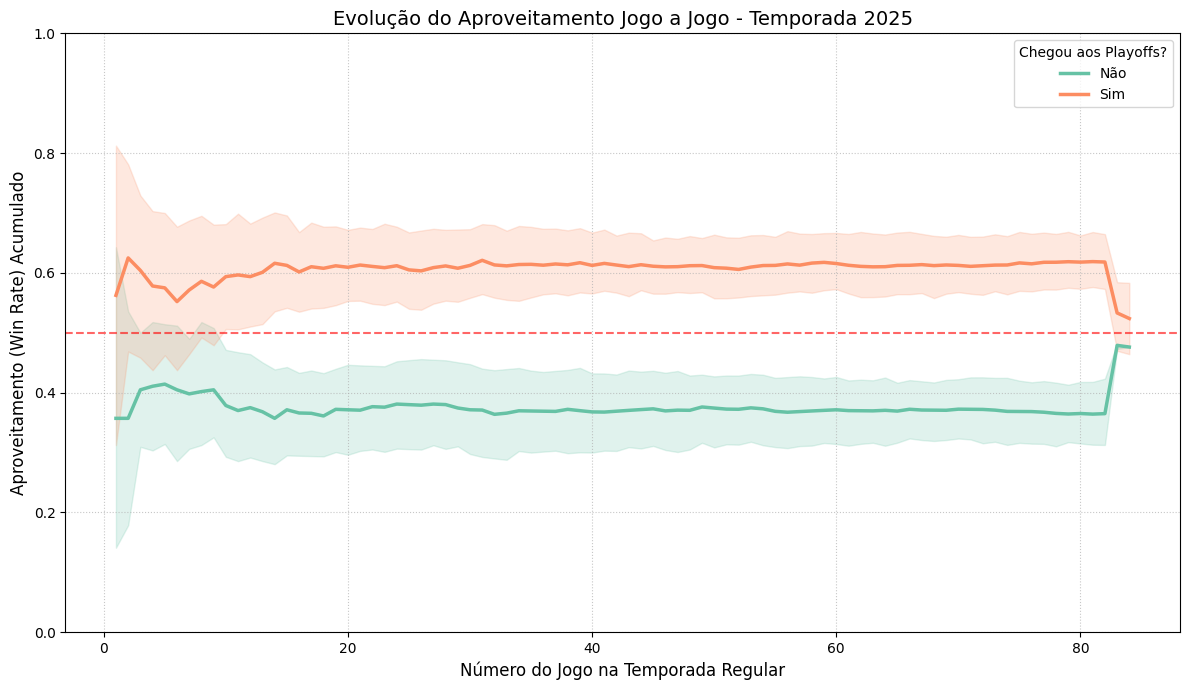

In [47]:
temporada_alvo = 2025
df_ts = df_regular[df_regular["season"] == temporada_alvo].copy()

#adicionando playoffs no df
df_ts = df_ts.merge(playoffs[["team", "season", "Playoff"]], on=["team", "season"], how="inner")

#rótulo
df_ts["Status_Playoff"] = df_ts["Playoff"].map({1: "Sim", 0: "Não"})

df_ts["Vitorias_Acumuladas"] = df_ts.groupby("team")["Win"].cumsum()

df_ts["Win_Rate_Acumulado"] = df_ts["Vitorias_Acumuladas"] / df_ts["Game_Number"]

plt.figure(figsize=(12, 7))

sns.lineplot(
    data=df_ts,
    x="Game_Number",
    y="Win_Rate_Acumulado",
    hue="Status_Playoff",
    palette="Set2",
    linewidth=2.5
)

plt.title(f"Evolução do Aproveitamento Jogo a Jogo - Temporada {temporada_alvo}", fontsize=14)
plt.xlabel("Número do Jogo na Temporada Regular", fontsize=12)
plt.ylabel("Aproveitamento (Win Rate) Acumulado", fontsize=12)
plt.legend(title="Chegou aos Playoffs?")
plt.grid(True, linestyle=':', alpha=0.7)
plt.ylim(0, 1)
plt.axhline(0.50, color="red", linestyle="--", alpha=0.6, label="Marca de 50% (0.50)")

plt.tight_layout()
plt.show()

Análise:

A separação de desempenho entre os classificados e eliminados se estabelece rapidamente, ficando nítida logo nos primeiros 15 jogos da temporada. Os times de playoff mantem-se consistentemente acima dessa linha de 50% o ano todo. A estabilidade das curvas comprova que a consistência domina a liga; após o terço inicial do campeonato, grandes reviravoltas no rendimento acumulado são raras. Por fim, também fizemos a análise individual de cada time.

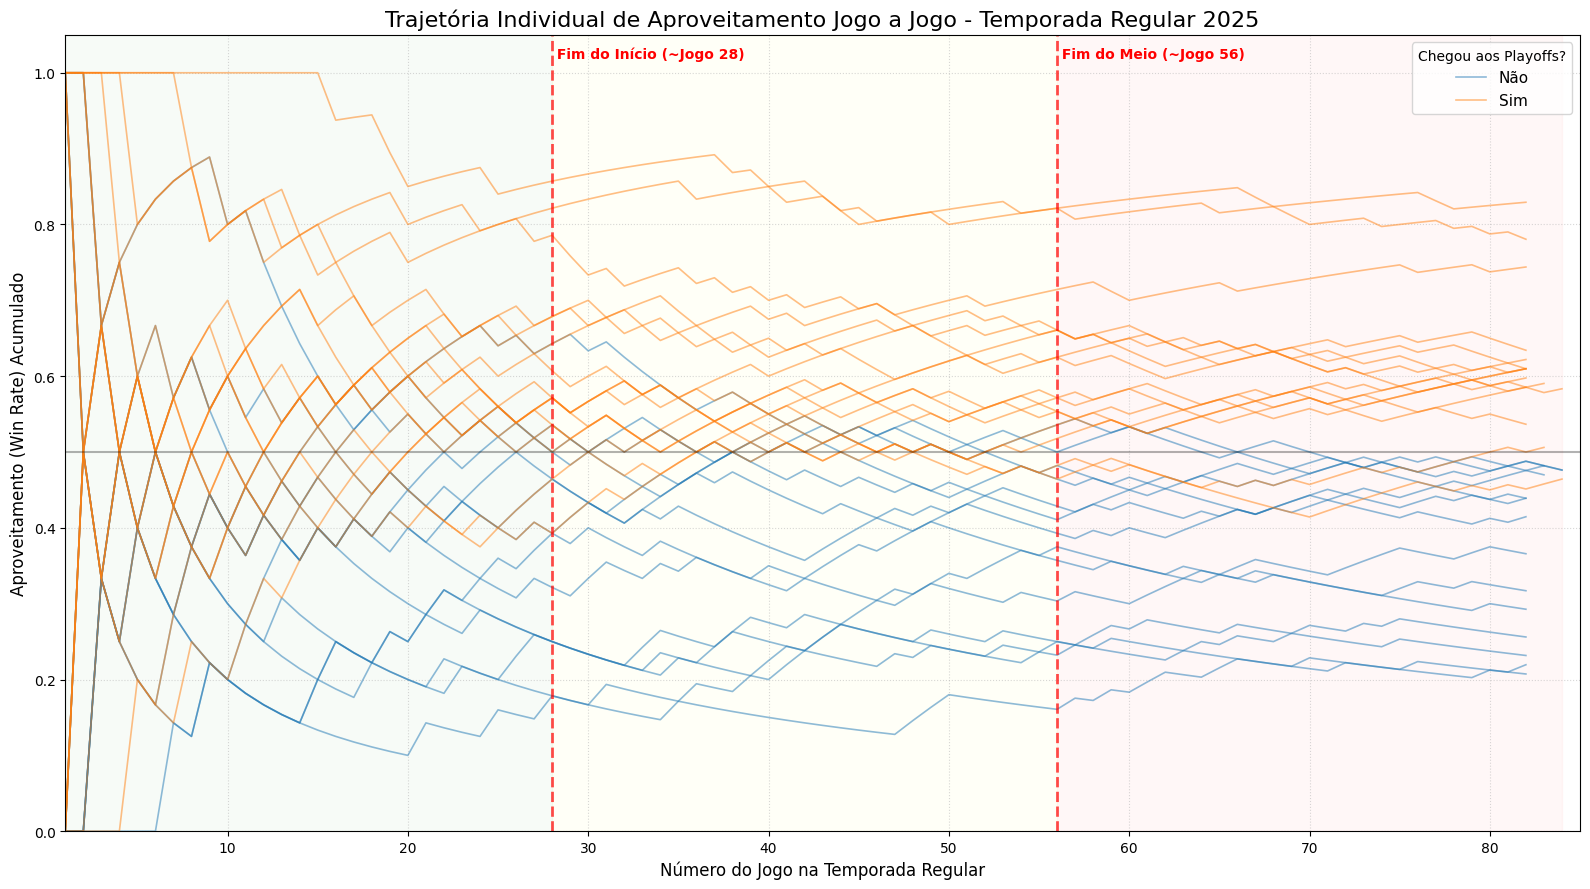

In [48]:
max_jogos = df_ts["Game_Number"].max()
transicao_1 = max_jogos / 3
transicao_2 = (2 * max_jogos) / 3

cores_customizadas = {"Sim": "#ff7f0e", "Não": "#1f77b4"}

plt.figure(figsize=(16, 9))

sns.lineplot(
    data=df_ts,
    x="Game_Number",
    y="Win_Rate_Acumulado",
    hue="Status_Playoff",
    units="team",       
    estimator=None,     
    palette=cores_customizadas,
    linewidth=1.2,      
    alpha=0.5          
)

plt.title(f"Trajetória Individual de Aproveitamento Jogo a Jogo - Temporada Regular {temporada_alvo}", fontsize=16)
plt.xlabel("Número do Jogo na Temporada Regular", fontsize=12)
plt.ylabel("Aproveitamento (Win Rate) Acumulado", fontsize=12)
plt.ylim(0, 1.05) 
plt.xlim(1, max_jogos + 1)
plt.grid(True, linestyle=':', alpha=0.5)
plt.axhline(0.50, color="black", linestyle="-", alpha=0.3, label="Linha de 50%")

plt.axvline(transicao_1, color="red", linestyle="--", alpha=0.7, linewidth=2)
plt.text(transicao_1, 1.02, f" Fim do Início (~Jogo {int(transicao_1)})", color="red", fontsize=10, fontweight='bold', ha='left')
plt.axvline(transicao_2, color="red", linestyle="--", alpha=0.7, linewidth=2)
plt.text(transicao_2, 1.02, f" Fim do Meio (~Jogo {int(transicao_2)})", color="red", fontsize=10, fontweight='bold', ha='left')
plt.axvspan(1, transicao_1, color='green', alpha=0.03)
plt.axvspan(transicao_1, transicao_2, color='yellow', alpha=0.03)
plt.axvspan(transicao_2, max_jogos, color='red', alpha=0.03)

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles[:2], labels=labels[:2], title="Chegou aos Playoffs?", fontsize=11, loc="upper right")

plt.tight_layout()
plt.show()

In [49]:
#código usado para gerar a tabela usada no quinto capítulo

team_analysis.to_csv("team_analysis.csv", index=False)

Análise: 

Esse novo gráfico só reforça o comportamento que vimos anteriormente. A quantidade de dados torna ele difícil de ser interpretado. Vemos que mesmo com queda de Win Rate no final, alguns times ainda conseguem se classificar.

### 2.6 Conclusões

Os resultados indicam que chegar aos playoffs na NBA está muito mais associado à consistência ao longo da temporada do que a picos de desempenho ou evolução tardia. A separação entre classificados e eliminados ocorre cedo e se mantém estável, com a barreira dos 50% de aproveitamento sendo um forte indicativo de sucesso. Além disso, o padrão observado sugere que equipes que iniciam bem tendem a sustentar seu desempenho, enquanto recuperações extremas são raras.

## 3. Quais perfis de jogadores podem ser identificados a partir de métricas estatísticas e como eles se distribuem entre as posições?

### 3.1 Introdução

Nesta etapa, buscamos identificar e interpretar perfis de jogadores a partir de suas métricas estatísticas, indo além das posições tradicionais da NBA. Para isso, utilizamos técnicas de redução de dimensionalidade (PCA) para visualizar como os atletas se distribuem em um espaço de características, revelando gradientes entre jogo interior e de perímetro, bem como entre criação ofensiva e especialização.

A partir dessa estrutura, aplicamos um algoritmo de clusterização (K-Means) para agrupar jogadores com padrões estatísticos semelhantes, permitindo a definição de perfis táticos distintos. Em seguida, analisamos como esses clusters se relacionam com as posições nominais, evidenciando a flexibilidade dos papéis no basquete moderno e a sobreposição entre funções em quadra.

### 3.2 Dados Utilizados

* **`PlayerSeasonStats`**: Contém o registro detalhado das estatísticas avançadas e tradicionais de cada jogador por temporada.


Para mais informações sobre colunas, tipos de dado entre outras consultar [ColetaDeDados.MD](./coletaDosDados.MD)

In [50]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

### 3.3 Pré-Processamento e "Feature engineering"

In [51]:
stats = pd.read_csv("PlayerSeasonStats.csv")

#algumas tabelas usam Team outras usam Tm
if 'Team' in stats.columns and 'Tm' in stats.columns:
    stats['Tm'] = stats['Tm'].fillna(stats['Team'])
elif 'Team' in stats.columns:
    stats['Tm'] = stats['Team']

#filtros
if 'is_playoff' in stats.columns:
    stats = stats[stats['is_playoff'].isin([False, 'False', 'false', 0, '0'])].copy()

#verificação de tipos
colunas_numeric = ["WS", "VORP", "BPM", "MP", "season"] 
for col in colunas_numeric:
    if col in stats.columns:
        stats[col] = pd.to_numeric(stats[col], errors="coerce")

#remoção de ruido
stats = stats[~stats['Tm'].isin(['TOT', '2TM', '3TM', '4TM'])]

#filtro
stats = stats[stats['MP'] > 500]

stats["season"] = stats["season"].fillna(0).astype(int)
stats = stats.dropna(subset=["Tm", "season", "WS"])

#seleção de features
features = [
    '3PAr',
    'FTr',
    'TRB%',
    'AST%',
    'STL%',
    'BLK%',
    'USG%',
    'TS%'
]

X = stats[features].fillna(0)

#kmeans
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=5, random_state=42)
stats['Cluster'] = kmeans.fit_predict(X_scaled)

cluster_profile = stats.groupby('Cluster')[features].mean()

stats.head()

C:\Users\gsett\AppData\Local\Temp\ipykernel_19872\2842810819.py:1: DtypeWarning: Columns (3,28) have mixed types. Specify dtype option on import or set low_memory=False.
  stats = pd.read_csv("PlayerSeasonStats.csv")


,Rk,Player,Age,Team,Pos,G,GS,MP,PER,TS%,...,DBPM,BPM,VORP,Awards,season,is_playoff,Tm,Unnamed: 19,Unnamed: 24,Cluster
0,1.0,Michael Finley,26.0,DAL,SF,82.0,82.0,3464.0,19.2,0.522,...,-0.9,2.1,3.6,"MVP-13,AS",2000,False,DAL,NaN,NaN,1
1,2.0,Gary Payton,31.0,SEA,PG,82.0,82.0,3425.0,23.6,0.535,...,0.7,6.4,7.3,"MVP-6,DPOY-5,AS,NBA1,DEF1",2000,False,SEA,NaN,NaN,1
2,3.0,Latrell Sprewell,29.0,NYK,SF,82.0,82.0,3276.0,15.7,0.515,...,0.5,1.0,2.5,NaN,2000,False,NYK,NaN,NaN,1
3,4.0,Kevin Garnett,23.0,MIN,PF,81.0,81.0,3243.0,23.6,0.545,...,1.7,6.3,6.8,"MVP-2,DPOY-7,AS,NBA1,DEF1",2000,False,MIN,NaN,NaN,3
4,5.0,Shareef Abdur-Rahim,23.0,VAN,SF,82.0,82.0,3223.0,20.2,0.547,...,-0.4,2.2,3.4,NaN,2000,False,VAN,NaN,NaN,3


### 3.4 Análises Realizadas

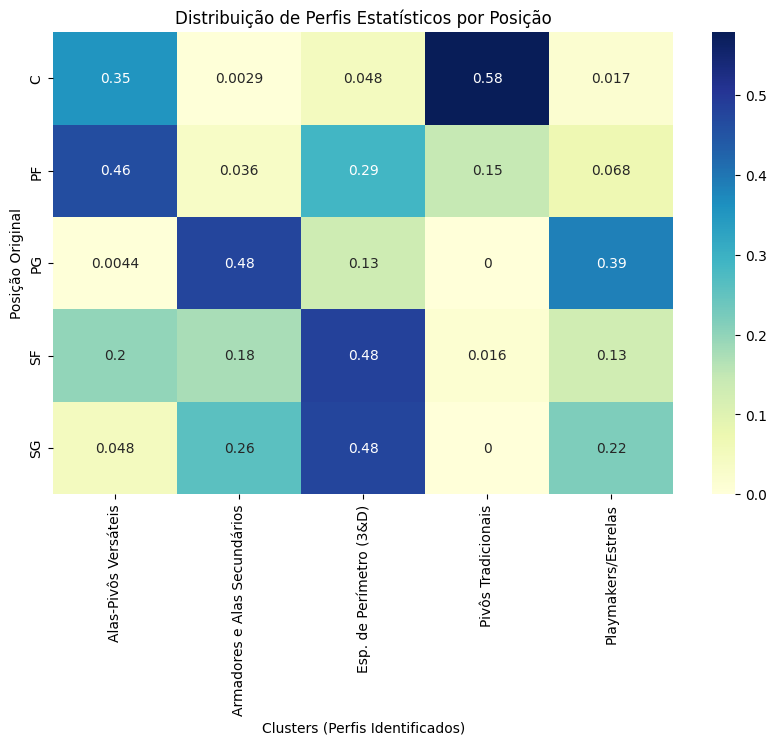

Cluster_Nome,Alas-Pivôs Versáteis,Armadores e Alas Secundários,Esp. de Perímetro (3&D),Pivôs Tradicionais,Playmakers/Estrelas
3PAr,0.088,0.298,0.501,0.050,0.290
FTr,0.300,0.229,0.189,0.444,0.326
TRB%,13.273,6.873,7.828,16.504,7.691
AST%,9.096,19.738,10.506,7.926,26.470
STL%,1.402,2.171,1.387,1.291,1.751
BLK%,2.010,0.808,1.112,4.262,0.889
USG%,18.864,18.161,17.109,17.499,25.988
TS%,0.518,0.501,0.555,0.586,0.557


In [52]:
plt.figure(figsize=(10,6))

#esse trecho vem da analise posterior, foi adicionado para aumentar legibilidade do gráfico
nomes_clusters = {
    0: "Pivôs Tradicionais",
    1: "Playmakers/Estrelas",
    2: "Armadores e Alas Secundários",
    3: "Alas-Pivôs Versáteis",
    4: "Esp. de Perímetro (3&D)"
}

stats['Cluster_Nome'] = stats['Cluster'].map(nomes_clusters)

ct = pd.crosstab(stats['Pos'], stats['Cluster_Nome'], normalize='index')

sns.heatmap(ct, annot=True, cmap="YlGnBu")
plt.title("Distribuição de Perfis Estatísticos por Posição")
plt.xlabel("Clusters (Perfis Identificados)")
plt.ylabel("Posição Original")
plt.show()

features_usadas = ['3PAr', 'FTr', 'TRB%', 'AST%', 'STL%', 'BLK%', 'USG%', 'TS%']
cluster_profile = stats.groupby('Cluster_Nome')[features_usadas].mean()

display(cluster_profile.T.round(3))

**Perfis de Jogadores Identificados (K-Means)**

* **Cluster 0: Pivôs Tradicionais (Rim Protectors).** Os donos do garrafão. Lideram em rebotes (TRB% 16.5), tocos (BLK% 4.26) e frequência de lances livres (FTr 0.444). Praticamente não arremessam de 3 (3PAr 0.05) e são altamente eficientes finalizando perto da cesta (TS% 0.586).
* **Cluster 1: Criadores de Jogadas (Primary Playmakers / Stars).** O motor do time. Lideram isolados no volume de jogo e criação, tendo o maior uso ofensivo (USG% 26.0) e taxa de assistências (AST% 26.5), mantendo uma eficiência sólida (TS% 0.557) para a alta carga que carregam.
* **Cluster 2: Armadores e Alas Secundários (Secondary Creators).** Atuam no perímetro, liderando a base em roubos de bola (STL% 2.17) e com boa taxa de assistências (AST% 19.7). Contudo, apresentam a pior eficiência real do modelo (TS% 0.501) e seguram menos a bola que as estrelas (USG% 18.1).
* **Cluster 3: Alas-Pivôs Versáteis (Scoring Bigs).** Misturam presença física com mobilidade. Apresentam ótimos números de rebote (TRB% 13.2) e proteção de aro (BLK% 2.01), segurando uma carga ofensiva relevante (USG% 18.8), mas ainda concentram seu jogo dentro do arco (3PAr 0.088).
* **Cluster 4: Especialistas de Perímetro (Spacers / 3&D).** Vivem na linha de 3 pontos: metade de todos os seus arremessos vêm de fora da linha de 3 pontos (3PAr 0.501). Seguram muito pouco a bola (baixo USG% de 17.1 e menor FTr de 0.189), mas são essenciais para espaçar a quadra com boa eficiência (TS% 0.555).

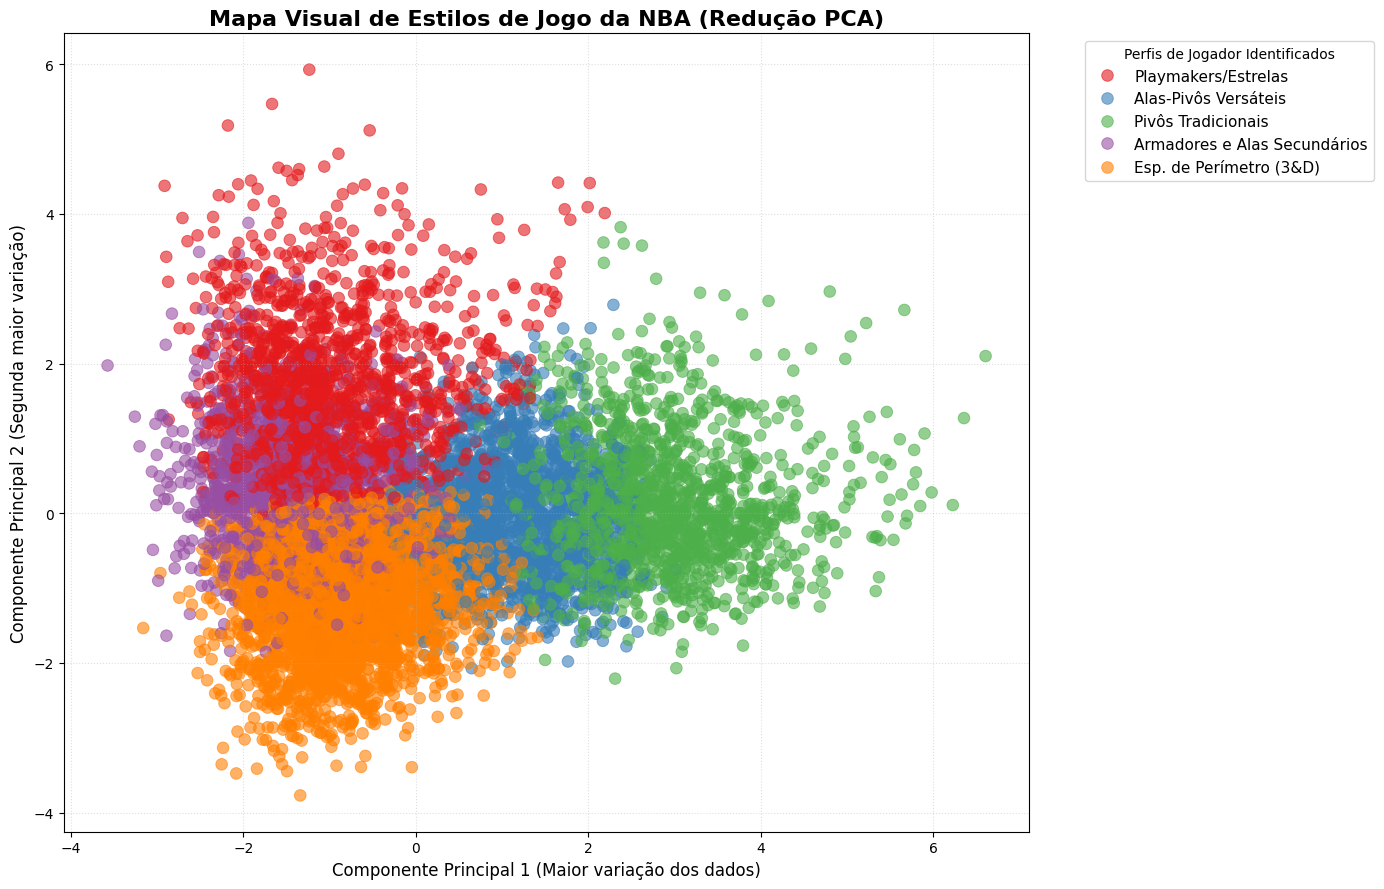

In [53]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

stats['PCA_X'] = X_pca[:, 0]
stats['PCA_Y'] = X_pca[:, 1]

nomes_clusters = {
    0: "Pivôs Tradicionais",
    1: "Playmakers/Estrelas",
    2: "Armadores e Alas Secundários",
    3: "Alas-Pivôs Versáteis",
    4: "Esp. de Perímetro (3&D)"
}
stats['Nome_Cluster'] = stats['Cluster'].map(nomes_clusters)
stats.to_csv("stats_players_com_clusters.csv", index=False)


plt.figure(figsize=(14, 9))

sns.scatterplot(
    data=stats, 
    x='PCA_X', 
    y='PCA_Y', 
    hue='Nome_Cluster', 
    palette='Set1',     
    alpha=0.6,          
    edgecolor=None,     
    s=70                
)

plt.title("Mapa Visual de Estilos de Jogo da NBA (Redução PCA)", fontsize=16, fontweight='bold')
plt.xlabel("Componente Principal 1 (Maior variação dos dados)", fontsize=12)
plt.ylabel("Componente Principal 2 (Segunda maior variação)", fontsize=12)

plt.legend(title="Perfis de Jogador Identificados", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)

plt.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()

plt.show()

Análise:

- **Componente Principal 1 (horizontal):** parece capturar a transição entre jogadores de garrafão (lado direito, maior TRB% e BLK%) e jogadores de perímetro (lado esquerdo, maior 3PAr e criação).
- **Componente Principal 2 (vertical):** diferencia principalmente volume ofensivo/criação (topo) de jogadores mais dependentes de finalização ou espaçamento (parte inferior).

- **Cluster 0 – Pivôs Tradicionais:**  
  Bem concentrados à direita, refletem forte presença física (rebotes e tocos). Baixa variabilidade indica um perfil bem definido e pouco híbrido.

- **Cluster 1 – Playmakers/Estrelas:**  
  Distribuídos mais ao topo, mostram alto uso e criação ofensiva. Há maior dispersão, sugerindo diferentes “tipos” de estrelas (mais pontuadores vs. mais passadores).

- **Cluster 2 – Criadores Secundários:**  
  Região intermediária, com sobreposição relevante com os playmakers. Isso indica uma transição natural entre estrelas e coadjuvantes criadores.

- **Cluster 3 – Alas-Pivôs Versáteis:**  
  Próximos dos pivôs, mas ligeiramente deslocados para o centro. Representam bem o perfil moderno de “bigs” mais móveis e com alguma versatilidade ofensiva.

- **Cluster 4 – Especialistas de Perímetro (3&D):**  
  Concentrados na parte inferior esquerda, com baixa criação e alto volume de arremessos de 3. Perfil bem definido e complementar taticamente.

- Existe uma clara separação entre **jogo interior (bigs)** e **jogo de perímetro**.
- A sobreposição entre **playmakers (C1)** e **criadores secundários (C2)** sugere que a criação ofensiva é um espectro, não uma categoria rígida.
- Os **especialistas de perímetro (C4)** são os mais distintos taticamente, reforçando seu papel específico de espaçamento.
- Os **alas-pivôs (C3)** funcionam como ponte entre o jogo tradicional de garrafão e o basquete moderno mais versátil.

In [54]:
#código utilizado para criar a tabela usada no próximo capítulo

stats.to_csv("stats_players_com_clusters.csv", index=False)

### 3.5 Conclusão

Nesta etapa, aplicamos o algoritmo K-Means sobre métricas estatísticas avançadas para agrupar os atletas em perfis táticos distintos, visualizando o espectro de estilos de jogo através da redução de dimensionalidade (PCA).
Em seguida, cruzamos esses agrupamentos matemáticos com as posições nominais da liga utilizando um mapa de calor para analisar a distribuição real e a sobreposição das funções em quadra.

### Extras: RadarChart e Expansão do Kmeans


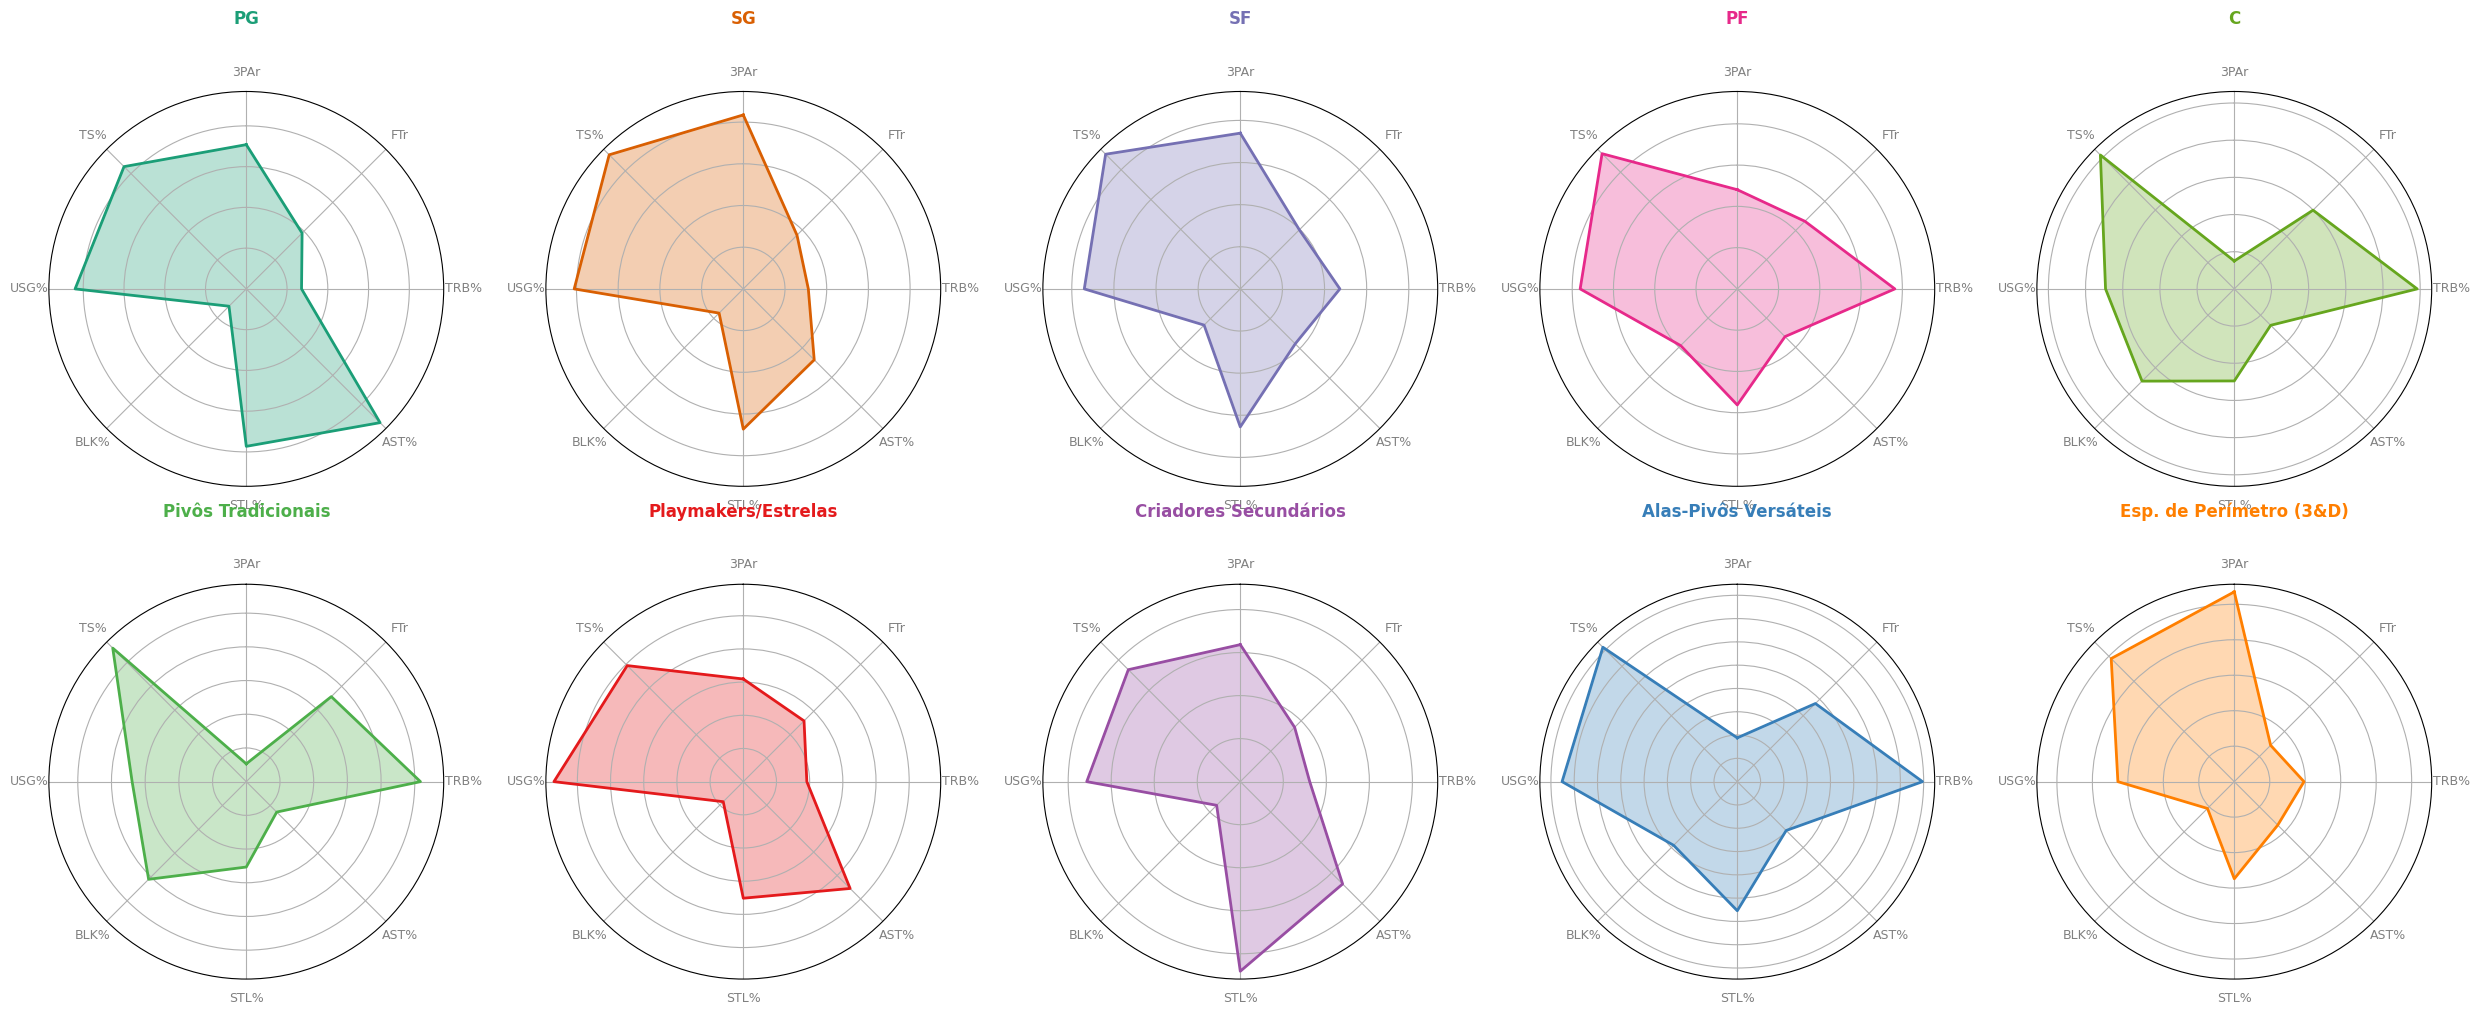

In [55]:
from math import pi
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt

scaler_radar = MinMaxScaler()
radar_data = pd.DataFrame(scaler_radar.fit_transform(stats[features]), columns=features)

radar_data['Cluster'] = stats['Cluster'].values
radar_data['Pos_Principal'] = stats['Pos'].astype(str).str.split('-').str[0].values

ordem_posicoes = ['PG', 'SG', 'SF', 'PF', 'C']

radar_pos_profile = radar_data.groupby('Pos_Principal')[features].mean().reindex(ordem_posicoes)
radar_profile = radar_data.groupby('Cluster')[features].mean().reset_index()

nomes_clusters = {
    0: "Pivôs Tradicionais",
    1: "Playmakers/Estrelas",
    2: "Criadores Secundários",
    3: "Alas-Pivôs Versáteis",
    4: "Esp. de Perímetro (3&D)"
}

cores_pos = ['#1b9e77', '#d95f02', '#7570b3', '#e7298a', '#66a61e']
cores_cluster = ['#4daf4a', '#e41a1c', '#984ea3', '#377eb8', '#ff7f00']

def plot_radar(row, title, color, num_grafico):
    categories = features
    N = len(categories)

    values = row[categories].values.flatten().tolist()
    values += values[:1]

    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    ax = plt.subplot(2, 5, num_grafico, polar=True)

    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)

    plt.xticks(angles[:-1], categories, size=9, color='grey')
    ax.set_yticklabels([])
    
    ax.plot(angles, values, color=color, linewidth=2, linestyle='solid')
    ax.fill(angles, values, color=color, alpha=0.3)

    plt.title(title, size=12, color=color, y=1.15, fontweight='bold')

plt.figure(figsize=(25, 10))

for i, row in radar_pos_profile.iterrows():
    plot_radar(row, i, cores_pos[ordem_posicoes.index(i)], ordem_posicoes.index(i) + 1)

radar_profile['Nome_Cluster'] = radar_profile['Cluster'].map(nomes_clusters)

for i, row in radar_profile.iterrows():
    plot_radar(row, row['Nome_Cluster'], cores_cluster[i], i + 6)

plt.tight_layout()
plt.show()

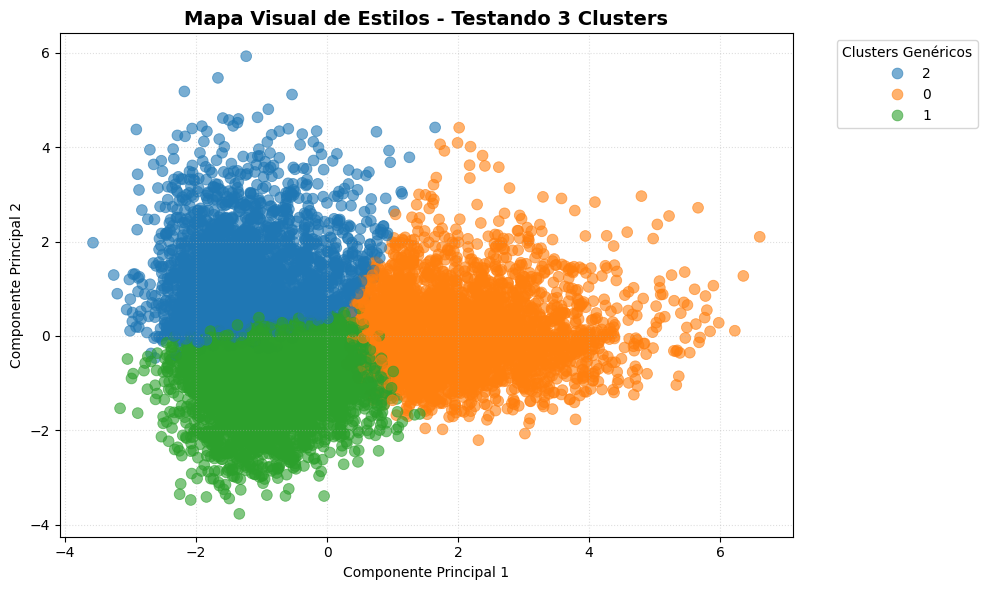

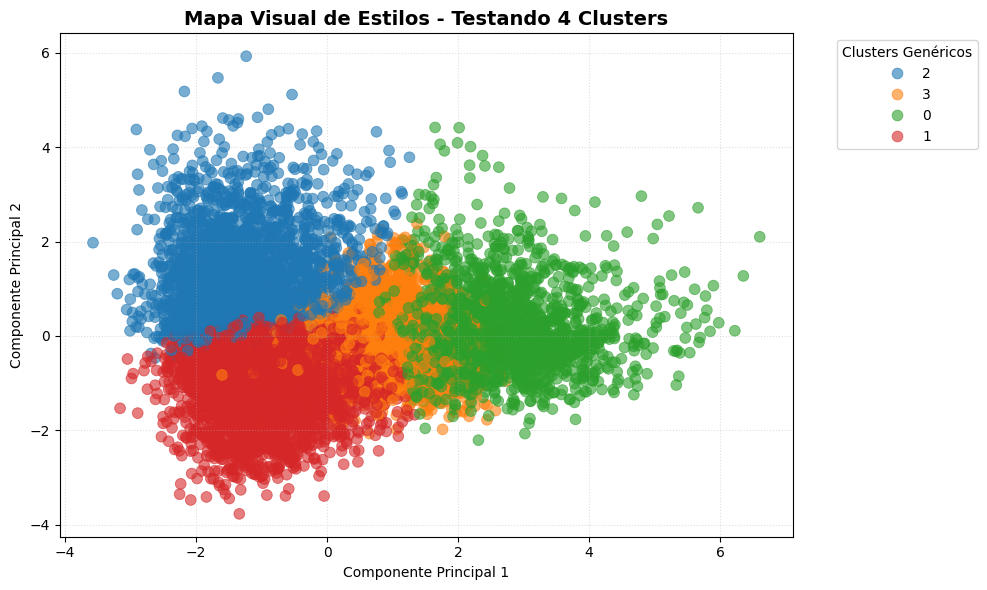

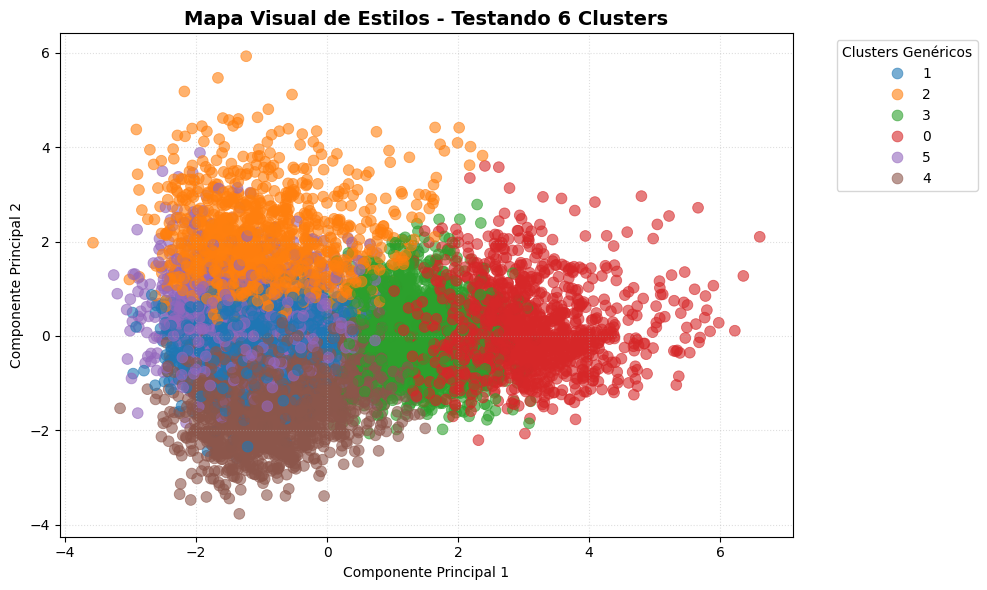

In [56]:
#Extra: verificando kmeans para outros números de clusters
testes_k = [3, 4, 6] 

for k in testes_k:
    kmeans_teste = KMeans(n_clusters=k, random_state=42)
    
    coluna_temp = f'Cluster_Test_{k}'
    stats[coluna_temp] = kmeans_teste.fit_predict(X_scaled)
    
    stats[coluna_temp] = stats[coluna_temp].astype(str)
    
    plt.figure(figsize=(10, 6))
    
    sns.scatterplot(
        data=stats, 
        x='PCA_X', 
        y='PCA_Y', 
        hue=coluna_temp, 
        palette='tab10',   
        alpha=0.6,          
        edgecolor=None,     
        s=60                
    )
    
    plt.title(f"Mapa Visual de Estilos - Testando {k} Clusters", fontsize=14, fontweight='bold')
    plt.xlabel("Componente Principal 1", fontsize=10)
    plt.ylabel("Componente Principal 2", fontsize=10)
    
    plt.legend(title="Clusters Genéricos", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.4)
    plt.tight_layout()
    
    plt.show()

## 4. Como a distribuição do impacto dos jogadores e as características estatísticas dos times influenciam o desempenho e a probabilidade de classificação para os playoffs?

## 4.1 Introdução

Além da força total dos elencos, tanto a forma como o impacto dos jogadores está distribuído quanto as características estatísticas e táticas das equipes podem influenciar diretamente o desempenho coletivo. Times altamente dependentes de poucos jogadores tendem a apresentar maior variabilidade ao longo da temporada, enquanto equipes mais equilibradas podem sustentar níveis de desempenho mais consistentes. Paralelamente, fatores como eficiência ofensiva e defensiva, estilo de jogo e composição dos perfis de jogadores também desempenham papel relevante nos resultados obtidos.

Nesse contexto, investiga-se como a distribuição do impacto individual, em conjunto com as características estatísticas e os perfis de jogo das equipes, se relaciona com o desempenho coletivo e a probabilidade de classificação para os playoffs.

## 4.2 Dados Utilizados

Nesta etapa final, cruzamos os resultados obtidos nos dois notebooks anteriores para entender a relação entre o talento individual e o sucesso coletivo:

* **`team_analysis` (Capítulo 2)**: Base consolidada com métricas de desempenho coletivo das equipes ao longo da temporada.  
Cada linha representa um time em uma temporada, com colunas como:  
  - `team` (*string*): identificação da equipe (ex: "ATL")  
  - `season` (*int*): temporada correspondente (ex: 2000)  
  - `Win_Inicio`, `Win_Meio`, `Win_Fim` (*float*): taxa de vitórias em diferentes fases da temporada  
  - `Evolucao` (*float*): variação de desempenho ao longo da temporada  
  - `Consistencia` (*float*): medida de estabilidade do desempenho  
  - `Playoff` (*int*): variável alvo (0 = não classificado, 1 = classificado)  

Exemplo:
`ATL, 2000, 0.407, 0.407, 0.214, -0.193, 0.111, 0`

---

* **`stats_players_com_clusters` (Capítulo 3)**: Base de estatísticas individuais enriquecida com a identificação de perfis de jogadores por meio de clusterização.  
Além das métricas tradicionais, foram adicionadas colunas como:  
  - `Cluster` (*int*): identificador numérico do grupo ao qual o jogador pertence  
  - `Nome_Cluster` (*string*): descrição do perfil do jogador (ex: "Playmakers/Estrelas")  
  - `PCA_X`, `PCA_Y` (*float*): coordenadas da redução de dimensionalidade para visualização  

Exemplo:
`Gary Payton, 2000, PG, TS%=0.535, AST%=37.7, Cluster=1, Nome_Cluster="Playmakers/Estrelas", PCA_X=-1.97, PCA_Y=2.46`

In [57]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 4.3 Pré-Processamento

In [58]:
df_players = pd.read_csv("stats_players_com_clusters.csv")
team_analysis = pd.read_csv("team_analysis.csv")

# Limpeza de colunas indesejadas
df_players = df_players.loc[:, ~df_players.columns.str.contains("Unnamed")]

# Conversões
cols_numeric = ["MP"]
for col in cols_numeric:
    df_players[col] = pd.to_numeric(df_players[col], errors="coerce")

df_players["season"] = pd.to_numeric(df_players["season"], errors="coerce").fillna(0).astype(int)

#filtro
df_players = df_players[df_players["MP"] > 500]

df_players = df_players.dropna(subset=["Tm", "season"])

# Padronização de nomes de times
df_players["Tm"] = df_players["Tm"].astype(str).str.strip().str.upper()
team_analysis["team"] = team_analysis["team"].astype(str).str.strip().str.upper()

print("Shape final df_players:", df_players.shape)
print("Shape team_analysis:", team_analysis.shape)

Shape final df_players: (9098, 37)
Shape team_analysis: (771, 8)


## 4.4 Feature Engineering

In [59]:
def role_tradicional(pos):
    if pd.isna(pos):
        return "Unknown"
    if "PG" in pos:
        return "PG"
    elif "SG" in pos:
        return "SG"
    elif "SF" in pos:
        return "SF"
    elif "PF" in pos:
        return "PF"
    elif "C" in pos:
        return "C"
    else:
        return "Other"
    
df_players["Role_Tradicional"] = df_players["Pos"].apply(role_tradicional)

role_distribution = df_players.groupby(
    ["Tm", "season", "Role_Tradicional"]
).size().unstack(fill_value=0)

role_distribution = role_distribution.div(
    role_distribution.sum(axis=1),
    axis=0
).reset_index()

print(role_distribution.head())

Role_Tradicional   Tm  season         C        PF        PG        SF  \
0                 5TM    2008  0.000000  0.000000  0.000000  1.000000   
1                 ATL    2000  0.200000  0.300000  0.200000  0.200000   
2                 ATL    2001  0.200000  0.133333  0.200000  0.333333   
3                 ATL    2002  0.166667  0.166667  0.166667  0.333333   
4                 ATL    2003  0.222222  0.111111  0.222222  0.222222   

Role_Tradicional        SG  
0                 0.000000  
1                 0.100000  
2                 0.133333  
3                 0.166667  
4                 0.222222  


In [60]:
cluster_distribution = df_players.groupby(
    ["Tm", "season", "Nome_Cluster"]
).size().unstack(fill_value=0)

cluster_distribution = cluster_distribution.div(
    cluster_distribution.sum(axis=1),
    axis=0
).reset_index()

print(cluster_distribution.head())

Nome_Cluster   Tm  season  Alas-Pivôs Versáteis  Armadores e Alas Secundários  \
0             5TM    2008              0.000000                      0.000000   
1             ATL    2000              0.500000                      0.300000   
2             ATL    2001              0.400000                      0.333333   
3             ATL    2002              0.500000                      0.333333   
4             ATL    2003              0.333333                      0.222222   

Nome_Cluster  Esp. de Perímetro (3&D)  Pivôs Tradicionais  Playmakers/Estrelas  
0                            1.000000            0.000000             0.000000  
1                            0.000000            0.100000             0.100000  
2                            0.066667            0.066667             0.133333  
3                            0.083333            0.000000             0.083333  
4                            0.111111            0.111111             0.222222  


In [61]:
team_features = cluster_distribution.merge(
    role_distribution,
    on=["Tm", "season"],
    how="inner"
)

print(team_features.shape)
team_features.head()

(776, 12)


,Tm,season,Alas-Pivôs Versáteis,Armadores e Alas Secundários,Esp. de Perímetro (3&D),Pivôs Tradicionais,Playmakers/Estrelas,C,PF,PG,SF,SG
0,5TM,2008,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
1,ATL,2000,0.500000,0.300000,0.000000,0.100000,0.100000,0.200000,0.300000,0.200000,0.200000,0.100000
2,ATL,2001,0.400000,0.333333,0.066667,0.066667,0.133333,0.200000,0.133333,0.200000,0.333333,0.133333
3,ATL,2002,0.500000,0.333333,0.083333,0.000000,0.083333,0.166667,0.166667,0.166667,0.333333,0.166667
4,ATL,2003,0.333333,0.222222,0.111111,0.111111,0.222222,0.222222,0.111111,0.222222,0.222222,0.222222


In [62]:
team_features["Criacao"] = (
    team_features["Playmakers/Estrelas"] +
    team_features["Armadores e Alas Secundários"]
)

team_features["Espacamento"] = team_features["Esp. de Perímetro (3&D)"]

team_features["Presenca_Garrafao"] = (
    team_features["Pivôs Tradicionais"] +
    team_features["Alas-Pivôs Versáteis"]
)

cluster_cols = [
    'Alas-Pivôs Versáteis',
    'Armadores e Alas Secundários',
    'Esp. de Perímetro (3&D)',
    'Pivôs Tradicionais',
    'Playmakers/Estrelas'
]

team_features["Versatilidade"] = team_features[cluster_cols].std(axis=1)

In [63]:
team_features = team_features.merge(
    team_analysis[[
        "team", "season",
        "Win_Inicio", "Win_Fim",
        "Evolucao", "Consistencia",
        "Playoff"
    ]],
    left_on=["Tm", "season"],
    right_on=["team", "season"],
    how="inner"
)

print("Distribuição de Playoffs:")
print(team_features["Playoff"].value_counts())

Distribuição de Playoffs:
Playoff
1    416
0    355
Name: count, dtype: int64


In [64]:
team_features = team_features.drop(columns=["team"])

team_features.head()

,Tm,season,Alas-Pivôs Versáteis,Armadores e Alas Secundários,Esp. de Perímetro (3&D),Pivôs Tradicionais,Playmakers/Estrelas,C,PF,PG,...,SG,Criacao,Espacamento,Presenca_Garrafao,Versatilidade,Win_Inicio,Win_Fim,Evolucao,Consistencia,Playoff
0,ATL,2000,0.500000,0.300000,0.000000,0.100000,0.100000,0.200000,0.300000,0.200000,...,0.100000,0.400000,0.000000,0.600000,0.200000,0.407407,0.214286,-0.193122,0.111499,0
1,ATL,2001,0.400000,0.333333,0.066667,0.066667,0.133333,0.200000,0.133333,0.200000,...,0.133333,0.466667,0.066667,0.466667,0.156347,0.333333,0.250000,-0.083333,0.048113,0
2,ATL,2002,0.500000,0.333333,0.083333,0.000000,0.083333,0.166667,0.166667,0.166667,...,0.166667,0.416667,0.083333,0.500000,0.209165,0.370370,0.500000,0.129630,0.087515,0
3,ATL,2003,0.333333,0.222222,0.111111,0.111111,0.222222,0.222222,0.111111,0.222222,...,0.222222,0.444444,0.111111,0.444444,0.092962,0.407407,0.535714,0.128307,0.102394,0
4,ATL,2004,0.500000,0.250000,0.083333,0.083333,0.083333,0.250000,0.166667,0.166667,...,0.250000,0.333333,0.083333,0.583333,0.182574,0.259259,0.357143,0.097884,0.075339,0


## 4.5 Análises Feitas

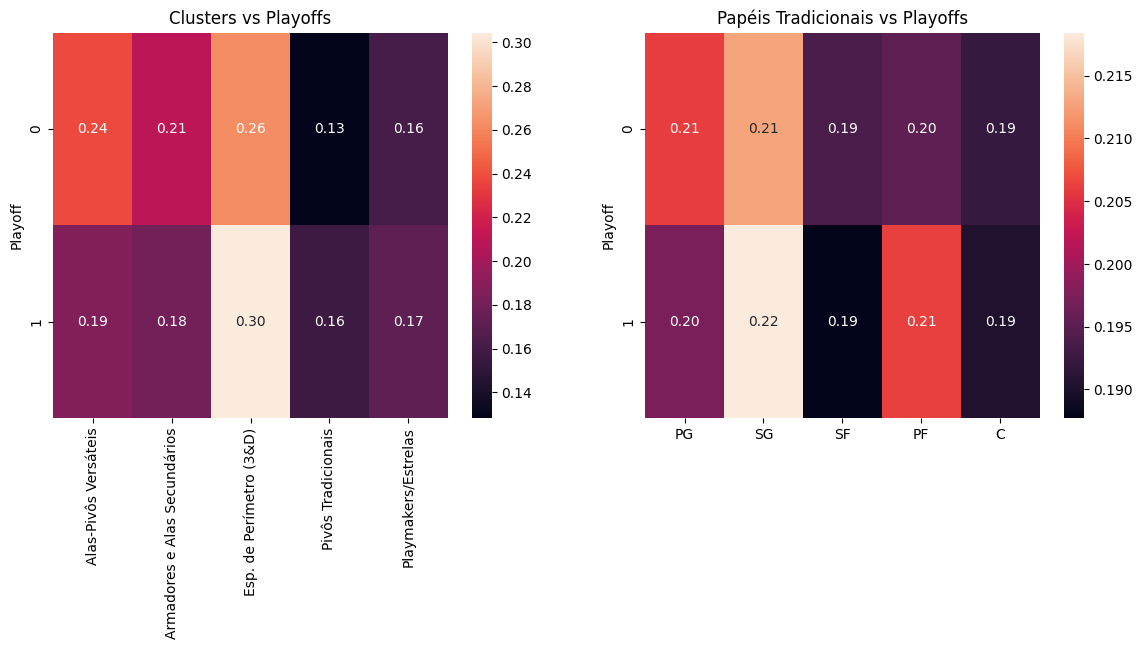

In [65]:
cluster_cols = [
    'Alas-Pivôs Versáteis',
    'Armadores e Alas Secundários',
    'Esp. de Perímetro (3&D)',
    'Pivôs Tradicionais',
    'Playmakers/Estrelas'
]

role_cols = ["PG", "SG", "SF", "PF", "C"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Clusters
sns.heatmap(
    team_features.groupby("Playoff")[cluster_cols].mean(),
    annot=True,
    fmt=".2f",
    ax=axes[0]
)
axes[0].set_title("Clusters vs Playoffs")

# Papéis tradicionais
sns.heatmap(
    team_features.groupby("Playoff")[role_cols].mean(),
    annot=True,
    fmt=".2f",
    ax=axes[1]
)
axes[1].set_title("Papéis Tradicionais vs Playoffs")

plt.show()

C:\Users\gsett\AppData\Local\Temp\ipykernel_19872\4266322617.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=team_features, x="Playoff", y=metric, ax=axes[i], palette="Set2")
C:\Users\gsett\AppData\Local\Temp\ipykernel_19872\4266322617.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=team_features, x="Playoff", y=metric, ax=axes[i], palette="Set2")
C:\Users\gsett\AppData\Local\Temp\ipykernel_19872\4266322617.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=team_features, x="Playoff", y=metric, ax=axes[i], palette="Se

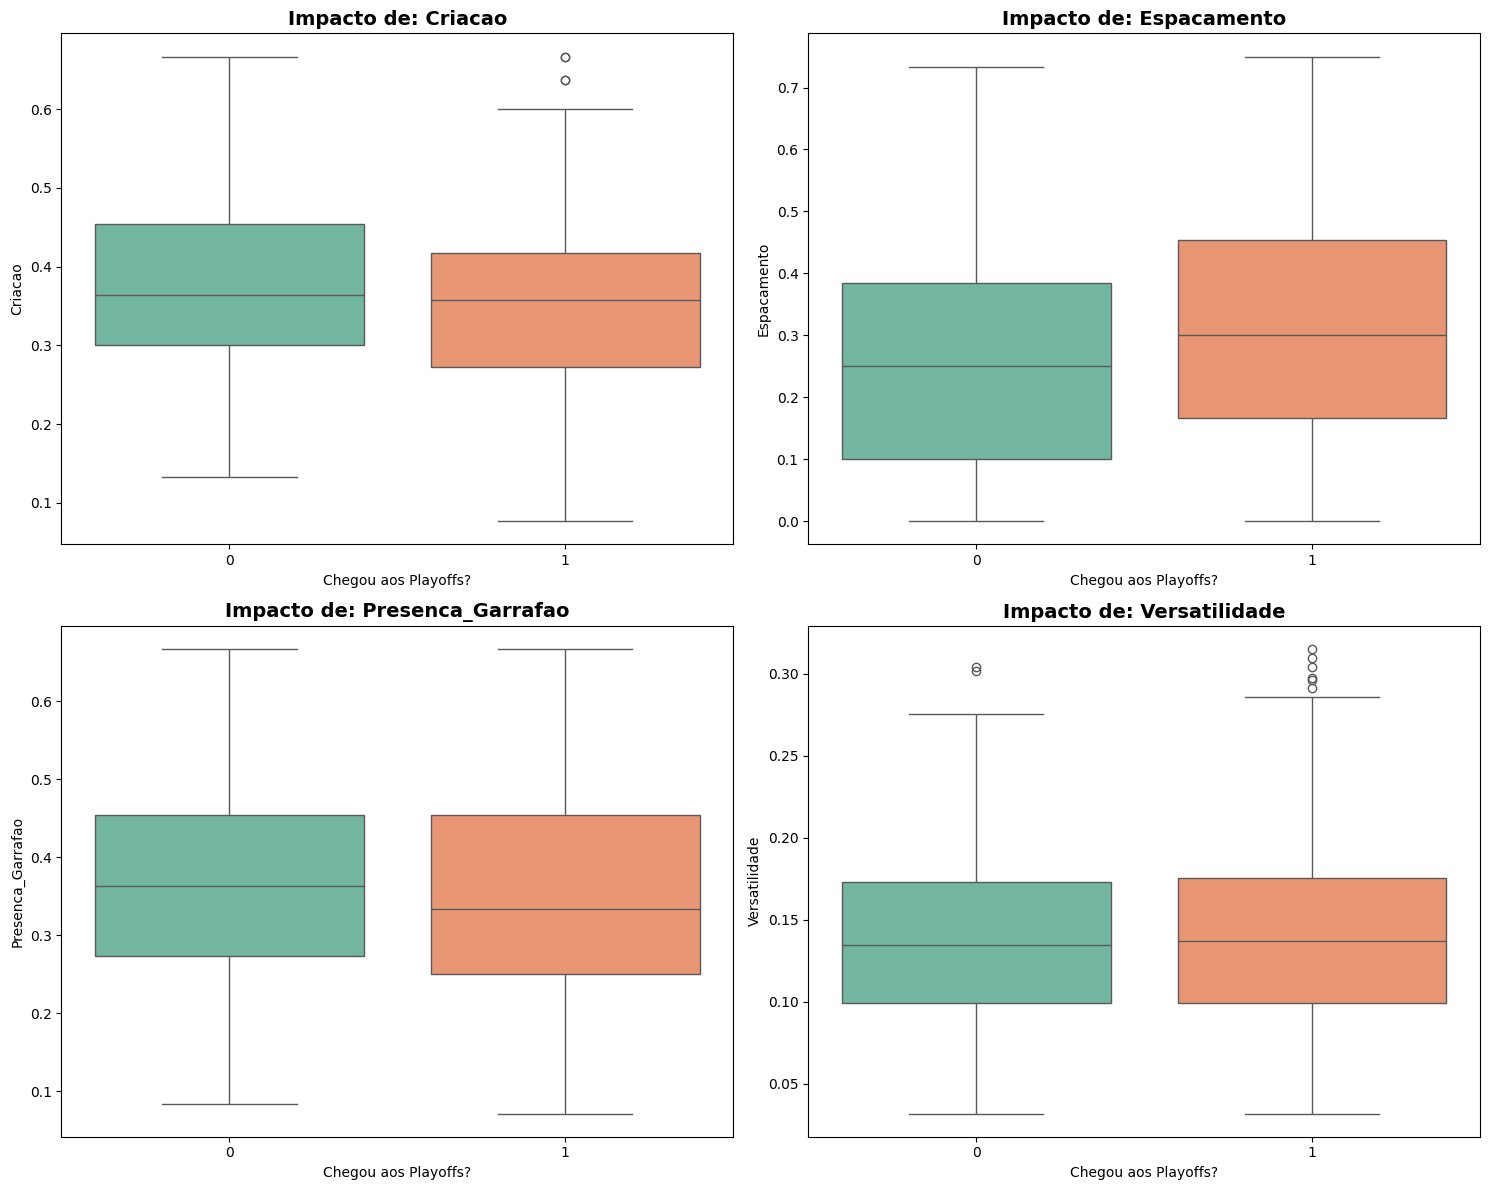

In [66]:
metrics = ["Criacao", "Espacamento", "Presenca_Garrafao", "Versatilidade"]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

axes = axes.flatten()

for i, metric in enumerate(metrics):
    sns.boxplot(data=team_features, x="Playoff", y=metric, ax=axes[i], palette="Set2")
    axes[i].set_title(f"Impacto de: {metric}", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Chegou aos Playoffs?")
    axes[i].set_ylabel(metric)

plt.tight_layout()
plt.show()

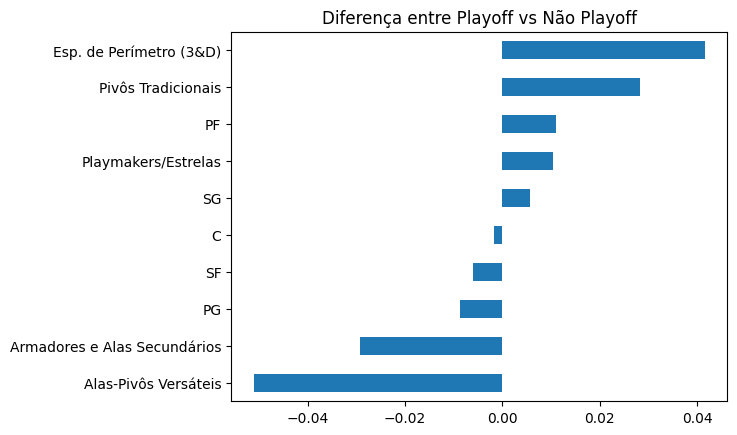

In [67]:
diff = (
    team_features.groupby("Playoff")[cluster_cols + role_cols]
    .mean()
    .diff()
    .iloc[-1]
    .sort_values()
)

diff.plot(kind="barh")
plt.title("Diferença entre Playoff vs Não Playoff")
plt.show()

## 4.6 Conclusão

A análise conjunta entre distribuição de perfis de jogadores e características estatísticas dos times indica que o sucesso na NBA está mais associado às funções exercidas em quadra do que às posições tradicionais.

Em primeiro lugar, observa-se que a distribuição por posição (PG, SG, SF, PF, C) é semelhante entre equipes classificadas e não classificadas, enquanto a segmentação por clusters de habilidades evidencia diferenças claras, reforçando que o desempenho é determinado pelo perfil técnico, e não pela posição nominal.

Além disso, times de playoff apresentam maior presença de especialistas de perímetro (3&D) e melhor capacidade de espaçamento de quadra, sugerindo que eficiência ofensiva e aproveitamento de arremessos são fatores determinantes para a classificação.

Por fim, a análise aponta que elencos mais equilibrados, com funções bem definidas e sem excesso de jogadores de perfil generalista, tendem a performar melhor, destacando a importância do encaixe entre habilidades complementares na construção de equipes competitivas.

## 5. As trades realizadas durante a temporada resultam em melhora significativa na performance das equipes?

### 5.1 Introdução

Ao longo de uma temporada da NBA, as equipes frequentemente recorrem a trades como forma de ajustar seus elencos, seja para corrigir deficiências específicas, reforçar a rotação ou aumentar seu potencial competitivo. Essas movimentações representam intervenções diretas na estrutura dos times, com o objetivo de impactar o desempenho no curto prazo.

No entanto, nem sempre é claro se essas mudanças de fato resultam em melhorias mensuráveis. Fatores como adaptação dos jogadores, encaixe tático e contexto competitivo podem influenciar significativamente os resultados, tornando o efeito das trades menos trivial do que aparenta.

Diante disso, esta pergunta tem como objetivo analisar se as trades realizadas durante a temporada estão associadas a melhorias significativas na performance das equipes, considerando indicadores de desempenho antes e depois dessas movimentações.

### 5.2 Dados utilizados

* **`TeamGames`**: Base que contém o registro jogo a jogo das partidas da NBA a partir da temporada de 2000. A partir dela, é possível calcular métricas de desempenho ao longo da temporada, como vitórias, evolução por fase (início, meio e fim) e consistência das equipes.
* **`TeamSeasonOutcomes`**: Consolida os resultados finais das temporadas, incluindo a variável alvo da análise (`Playoff`), indicando se a equipe conseguiu ou não alcançar a pós-temporada.
* **`trades`**: Base que registra as movimentações de jogadores entre equipes a partir de 2000, permitindo identificar entradas e saídas de atletas por time e data, além de quantificar o volume de trades ao longo das temporadas.

Para mais informações sobre colunas, tipos de dado entre outras, consultar [ColetaDeDados.MD](./coletaDosDados.MD)

In [68]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

### 5.3 Pré-Processamento + Feature Engenieering

In [69]:
#reaproveitando da primeira pergunta

TeamGames = pd.read_csv(
    "TeamGames.csv",
    engine="python",
    on_bad_lines="skip"
)

TeamGames = TeamGames.loc[:, ~TeamGames.columns.str.contains("Unnamed")] #remoção de colunas "fantasmas"

#garantindo tipo de dado
TeamGames["Date"] = pd.to_datetime(TeamGames["Date"], errors="coerce")
TeamGames["Tm"] = pd.to_numeric(TeamGames["Tm"], errors="coerce")
TeamGames["Opp"] = pd.to_numeric(TeamGames["Opp"], errors="coerce")
TeamGames["season"] = pd.to_numeric(TeamGames["season"], errors="coerce")

#útil para a aplicação de filtro posterior
TeamGames["is_playoff"] = TeamGames["is_playoff"].isin([True, 'True', 'true', 1, '1'])
TeamGames["team"] = TeamGames["team"].astype(str).str.strip()
TeamGames = TeamGames.dropna(subset=["Date", "team", "Tm", "Opp", "season"])

TeamSeasonOutcomes = pd.read_csv("team_season_outcomes.csv")

playoffs = TeamSeasonOutcomes[["team", "season", "reached_playoffs"]].copy() #só vamos usar essas colunas

#renomear + garantindo tipos
playoffs = playoffs.rename(columns={"reached_playoffs": "Playoff"})
playoffs["Playoff"] = playoffs["Playoff"].astype(int)
playoffs["season"] = pd.to_numeric(playoffs["season"], errors="coerce")
playoffs["team"] = playoffs["team"].astype(str).str.strip()

#filtro + cálculo de vitórias
df_regular = TeamGames[~TeamGames["is_playoff"]].copy()
df_regular["Win"] = (df_regular["Tm"] > df_regular["Opp"]).astype(int)

#ordenação
df_regular = df_regular.sort_values(by=["team", "season", "Date"])
df_regular["Game_Number"] = df_regular.groupby(["team", "season"]).cumcount() + 1

#criação dos períodos a serem analisados
df_regular["Season_Phase"] = df_regular.groupby(["team", "season"])["Game_Number"].transform(
    lambda x: pd.cut(
        x,
        bins=[0, x.max()/3, 2*x.max()/3, x.max()],
        labels=["Início", "Meio", "Fim"]
    )
)

df_games = df_regular.copy()

df_games["team"] = df_games["team"].str.strip().str.upper()
df_games["Date"] = pd.to_datetime(df_games["Date"])
df_games = df_games.sort_values(["team", "season", "Date"])

In [70]:
df_trades = pd.read_csv("trades.csv")

#filtra as picks
df_trades = df_trades[df_trades["asset_type"] == "player"].copy()

df_trades["date"] = pd.to_datetime(df_trades["date"])

df_in = df_trades.rename(columns={
    "team_to": "team",
    "asset_name": "player"
})[["team", "date", "player"]]

df_in["type"] = "in"

df_out = df_trades.rename(columns={
    "team_from": "team",
    "asset_name": "player"
})[["team", "date", "player"]]

df_out["type"] = "out"

df_moves = pd.concat([df_in, df_out], ignore_index=True)
df_moves["team"] = df_moves["team"].str.strip().str.upper()

trade_summary = df_moves.groupby(["team", "date", "type"])["player"] \
    .count().unstack(fill_value=0).reset_index()

trade_summary["team"] = trade_summary["team"].str.strip().str.upper()

trade_summary = trade_summary.rename(columns={
    "in": "players_in",
    "out": "players_out"
})

### 5.4 Feature Engineering

In [71]:
trade_summary["season"] = trade_summary["date"].apply(
    lambda x: x.year + 1 if x.month >= 10 else x.year
)

trade_summary["team"] = trade_summary["team"].str.strip().str.upper()
df_games["team"] = df_games["team"].str.strip().str.upper()

#trecho incluido por causa de problema encontrado ao realizar debug
team_map = {
    "NEW JERSEY NETS": "BRK",
    "CHARLOTTE BOBCATS": "CHA",
    "CHARLOTTE HORNETS": "CHA",
    "VANCOUVER GRIZZLIES": "MEM",
    "SEATTLE SUPERSONICS": "OKC"
}

trade_summary["team"] = trade_summary["team"].replace(team_map)

trade_filtered = trade_summary[
    (trade_summary["date"].dt.month >= 10) | 
    (trade_summary["date"].dt.month <= 4)
]

first_trade = trade_filtered.sort_values(["team", "season", "date"]) \
    .groupby(["team", "season"]) \
    .first() \
    .reset_index()

def compute_pre_post(team, season, trade_date, games_df):
    
    df_team = games_df[
        (games_df["team"] == team) &
        (games_df["season"] == season)
    ]
    
    if df_team.empty:
        return None
    
    pre = df_team[df_team["Date"] < trade_date]
    post = df_team[df_team["Date"] > trade_date]
    
    if len(pre) < 5 or len(post) < 5:
        return None
    
    return {
        "team": team,
        "season": season,
        "trade_date": trade_date,
        "pre_win": pre["Win"].mean(),
        "post_win": post["Win"].mean(),
        "delta": post["Win"].mean() - pre["Win"].mean(),
        "n_pre_games": len(pre),
        "n_post_games": len(post)
    }

results = []

for _, row in first_trade.iterrows():
    
    res = compute_pre_post(
        row["team"],
        row["season"],
        row["date"],
        df_games
    )
    
    if res is not None:
        results.append(res)

df_trade_impact = pd.DataFrame(results)
df_trade_impact.head()

,team,season,trade_date,pre_win,post_win,delta,n_pre_games,n_post_games
0,ATL,2000,2000-02-24,0.411765,0.225806,-0.185958,51,31
1,ATL,2001,2001-01-02,0.333333,0.274510,-0.058824,30,51
2,ATL,2004,2004-02-09,0.326923,0.344828,0.017905,52,29
3,ATL,2005,2004-12-23,0.200000,0.140351,-0.059649,25,57
4,ATL,2007,2007-02-22,0.388889,0.321429,-0.067460,54,28


### 5.5 Análises Realizadas

In [72]:
#trades mais impactantes

print(len(df_trade_impact))
df_trade_impact.sort_values("delta", ascending=False).head(5)

411


,team,season,trade_date,pre_win,post_win,delta,n_pre_games,n_post_games
95,DEN,2005,2005-02-24,0.462963,0.857143,0.394180,54,28
390,UTA,2018,2018-02-08,0.481481,0.785714,0.304233,54,28
388,UTA,2015,2015-02-19,0.358491,0.655172,0.296682,53,29
286,ORL,2019,2019-02-07,0.407407,0.703704,0.296296,54,27
296,PHI,2007,2006-12-19,0.217391,0.508475,0.291083,23,59


Exemplo das primeira trade:

![Printscreen do site basketball reference mostrando a trade mais impactante](exemplo_trade.png)

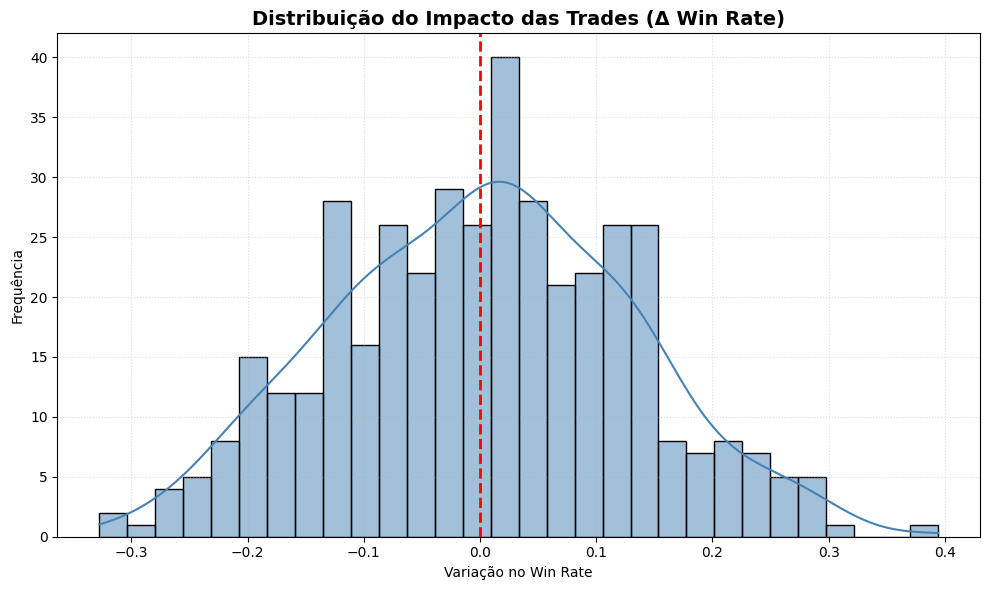

np.float64(0.5158150851581509)

In [73]:
plt.figure(figsize=(10,6))
sns.histplot(
    df_trade_impact["delta"],
    bins=30,
    kde=True,
    color="steelblue",
    edgecolor="black"
)

plt.axvline(0, color="red", linestyle="--", linewidth=2)

plt.title("Distribuição do Impacto das Trades (Δ Win Rate)", fontsize=14, fontweight='bold')
plt.xlabel("Variação no Win Rate")
plt.ylabel("Frequência")

plt.grid(True, linestyle=":", alpha=0.4)

plt.tight_layout()
plt.show()
(df_trade_impact["delta"] > 0).mean()

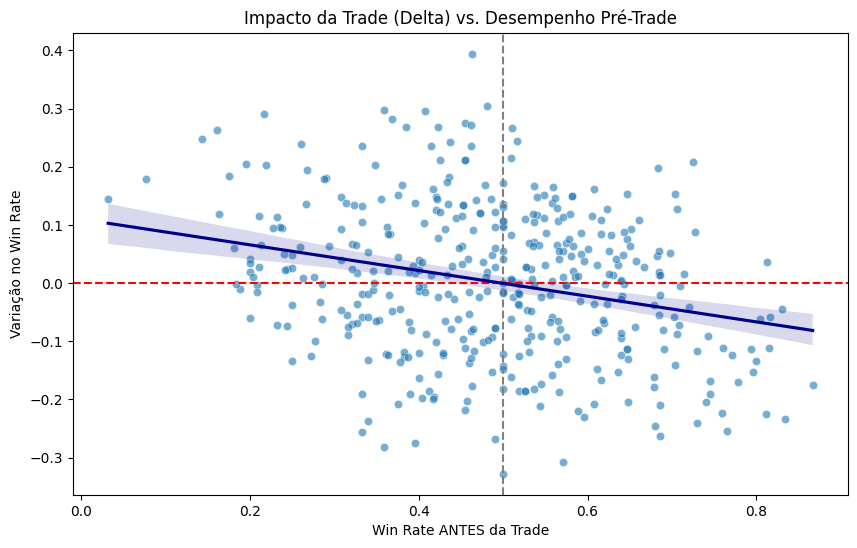

In [74]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_trade_impact, 
    x="pre_win", 
    y="delta",
    alpha=0.6
)

plt.axhline(0, color='red', linestyle='--')
plt.axvline(0.5, color='gray', linestyle='--')

sns.regplot(data=df_trade_impact, x="pre_win", y="delta", scatter=False, color='darkblue')

plt.title("Impacto da Trade (Delta) vs. Desempenho Pré-Trade")
plt.xlabel("Win Rate ANTES da Trade")
plt.ylabel("Variação no Win Rate")
plt.show()

### 5.6 Conclusão

A análise da distribuição e do contexto pré-trade revela que as trocas de jogadores, de forma geral, não atuam como soluções mágicas ou imediatas para o desempenho de uma franquia.

Ao observar o histograma, constatamos que o impacto médio (variação do *Win Rate*) é apenas muito levemente positivo, concentrando-se fortemente ao redor do zero. A alta dispersão dos dados mostra que o cenário é incerto: a frequência com que as equipes pioram após uma troca é quase tão alta quanto a frequência com que melhoram. O ato de realizar uma trade, por si só, não garante sucesso.

A maior revelação, no entanto, vem do cruzamento com o desempenho anterior (gráfico de dispersão), que ilustra um claro fenômeno de **regressão à média**. Existe uma nítida tendência de baixa: times com campanhas ruins (Win Rate abaixo de 0.5) concentram os maiores saltos de melhora, o que é natural, pois têm uma margem de crescimento muito maior. Por outro lado, times da elite (Win Rate acima de 0.6) frequentemente sofrem quedas de rendimento.

## 6. Como o impacto das trades pode ser quantificado em termos de probabilidade de classificação para os playoffs e avanço nas fases finais?

### 6.1 Introdução

Nesta etapa, buscamos quantificar o impacto das trades em termos de probabilidade de sucesso, indo além de métricas tradicionais como vitórias ou derrotas. Para isso, adotamos uma abordagem de modelagem probabilística, que permite estimar como a composição do elenco influencia diretamente a chance de uma equipe alcançar os playoffs.

A análise é construída a partir da comparação entre a probabilidade de classificação antes e após as movimentações de jogadores, possibilitando medir o efeito marginal das trades no desempenho das equipes.

### 6.2 Dados utilizados

* **`TeamGames`**: Base que contém o registro jogo a jogo das partidas da NBA a partir da temporada de 2000. A partir dela, é possível calcular métricas de desempenho ao longo da temporada, como vitórias, evolução por fase (início, meio e fim) e consistência das equipes.
* **`TeamSeasonOutcomes`**: Consolida os resultados finais das temporadas, incluindo a variável alvo da análise (`Playoff`), indicando se a equipe conseguiu ou não alcançar a pós-temporada.
* **`trades`**: Base que registra as movimentações de jogadores entre equipes a partir de 2000, permitindo identificar entradas e saídas de atletas por time e data, além de quantificar o volume de trades ao longo das temporadas.

Para mais informações sobre colunas, tipos de dado entre outras, consultar [ColetaDeDados.MD](./coletaDosDados.MD)

### 6.3 Pré-processamento

In [75]:
df_outcomes = pd.read_csv("team_season_outcomes.csv")

df_outcomes = df_outcomes.rename(columns={
    "reached_playoffs": "Playoff",
    "reached_conf_finals": "Conf_Finals",
    "champion": "Champion"
})

df_outcomes["team"] = df_outcomes["team"].str.strip().str.upper()
df_outcomes["season"] = pd.to_numeric(df_outcomes["season"], errors="coerce")

df_outcomes = df_outcomes.dropna()

In [76]:
#reaproveitando dos pontos 2 e 5
TeamGames = pd.read_csv(
    "TeamGames.csv",
    engine="python",
    on_bad_lines="skip"
)

TeamGames = TeamGames.loc[:, ~TeamGames.columns.str.contains("Unnamed")]

TeamGames["Date"] = pd.to_datetime(TeamGames["Date"], errors="coerce")
TeamGames["Tm"] = pd.to_numeric(TeamGames["Tm"], errors="coerce")
TeamGames["Opp"] = pd.to_numeric(TeamGames["Opp"], errors="coerce")
TeamGames["season"] = pd.to_numeric(TeamGames["season"], errors="coerce")

TeamGames["is_playoff"] = TeamGames["is_playoff"].isin([True, 'True', 'true', 1, '1'])
TeamGames["team"] = TeamGames["team"].astype(str).str.strip()
TeamGames = TeamGames.dropna(subset=["Date", "team", "Tm", "Opp", "season"])

TeamSeasonOutcomes = pd.read_csv("team_season_outcomes.csv")

playoffs = TeamSeasonOutcomes[["team", "season", "reached_playoffs"]].copy()

playoffs = playoffs.rename(columns={"reached_playoffs": "Playoff"})
playoffs["Playoff"] = playoffs["Playoff"].astype(int)
playoffs["season"] = pd.to_numeric(playoffs["season"], errors="coerce")
playoffs["team"] = playoffs["team"].astype(str).str.strip()

df_regular = TeamGames[~TeamGames["is_playoff"]].copy()
df_regular["Win"] = (df_regular["Tm"] > df_regular["Opp"]).astype(int)

df_regular = df_regular.sort_values(by=["team", "season", "Date"])
df_regular["Game_Number"] = df_regular.groupby(["team", "season"]).cumcount() + 1

df_regular["Season_Phase"] = df_regular.groupby(["team", "season"])["Game_Number"].transform(
    lambda x: pd.cut(
        x,
        bins=[0, x.max()/3, 2*x.max()/3, x.max()],
        labels=["Início", "Meio", "Fim"]
    )
)

df_games = df_regular.copy()

df_games["team"] = df_games["team"].str.strip().str.upper()
df_games["Date"] = pd.to_datetime(df_games["Date"])
df_games = df_games.sort_values(["team", "season", "Date"])

df_trades = pd.read_csv("trades.csv")

df_trades = df_trades[df_trades["asset_type"] == "player"].copy()
df_trades["date"] = pd.to_datetime(df_trades["date"])

df_in = df_trades.rename(columns={
    "team_to": "team",
    "asset_name": "player"
})[["team", "date", "player"]]

df_in["type"] = "in"

df_out = df_trades.rename(columns={
    "team_from": "team",
    "asset_name": "player"
})[["team", "date", "player"]]

df_out["type"] = "out"

df_moves = pd.concat([df_in, df_out], ignore_index=True)
df_moves["team"] = df_moves["team"].str.strip().str.upper()

trade_summary = df_moves.groupby(["team", "date", "type"])["player"] \
    .count().unstack(fill_value=0).reset_index()

trade_summary["team"] = trade_summary["team"].str.strip().str.upper()

trade_summary = trade_summary.rename(columns={
    "in": "players_in",
    "out": "players_out"
})

trade_summary["net_players"] = trade_summary["players_in"] - trade_summary["players_out"]
trade_summary["total_moved"] = trade_summary["players_in"] + trade_summary["players_out"]

trade_summary["season"] = trade_summary["date"].apply(
    lambda x: x.year + 1 if x.month >= 10 else x.year
)

trade_summary["team"] = trade_summary["team"].str.strip().str.upper()
df_games["team"] = df_games["team"].str.strip().str.upper()

team_map = {
    "NEW JERSEY NETS": "BRK",
    "CHARLOTTE BOBCATS": "CHA",
    "CHARLOTTE HORNETS": "CHA",
    "VANCOUVER GRIZZLIES": "MEM",
    "SEATTLE SUPERSONICS": "OKC"
}

trade_summary["team"] = trade_summary["team"].replace(team_map)

trade_filtered = trade_summary[
    (trade_summary["date"].dt.month >= 10) | 
    (trade_summary["date"].dt.month <= 4)
]

first_trade = trade_filtered.sort_values(["team", "season", "date"]) \
    .groupby(["team", "season"]) \
    .first() \
    .reset_index()

def compute_pre_post(team, season, trade_date, games_df):
    
    df_team = games_df[
        (games_df["team"] == team) &
        (games_df["season"] == season)
    ]
    
    if df_team.empty:
        return None
    
    pre = df_team[df_team["Date"] < trade_date]
    post = df_team[df_team["Date"] > trade_date]
    
    if len(pre) < 5 or len(post) < 5:
        return None
    
    return {
        "team": team,
        "season": season,
        "trade_date": trade_date,
        "pre_win": pre["Win"].mean(),
        "post_win": post["Win"].mean(),
        "delta": post["Win"].mean() - pre["Win"].mean(),
        "n_pre_games": len(pre),
        "n_post_games": len(post)
    }

results = []

for _, row in first_trade.iterrows():
    
    res = compute_pre_post(
        row["team"],
        row["season"],
        row["date"],
        df_games
    )
    
    if res is not None:
        results.append(res)

df_trade_impact = pd.DataFrame(results)
print(df_trade_impact.head())

  team  season trade_date   pre_win  post_win     delta  n_pre_games  \
0  ATL    2000 2000-02-24  0.411765  0.225806 -0.185958           51   
1  ATL    2001 2001-01-02  0.333333  0.274510 -0.058824           30   
2  ATL    2004 2004-02-09  0.326923  0.344828  0.017905           52   
3  ATL    2005 2004-12-23  0.200000  0.140351 -0.059649           25   
4  ATL    2007 2007-02-22  0.388889  0.321429 -0.067460           54   

   n_post_games  
0            31  
1            51  
2            29  
3            57  
4            28  


### 6.4 Feature Engineering

In [77]:
def build_pre_post_features(team, season, trade_date, games_df):
    
    df_team = games_df[
        (games_df["team"] == team) &
        (games_df["season"] == season)
    ]
    
    if df_team.empty:
        return None
    
    pre = df_team[df_team["Date"] < trade_date]
    post = df_team[df_team["Date"] > trade_date]
    
    if len(pre) < 5 or len(post) < 5:
        return None
    
    return {
        "team": team,
        "season": season,
        "trade_date": trade_date,
        
        "pre_win": pre["Win"].mean(),
        "pre_games": len(pre),
        
        "post_win": post["Win"].mean(),
        "post_games": len(post)
    }

results = []

for _, row in first_trade.iterrows():
    
    res = build_pre_post_features(
        row["team"],
        row["season"],
        row["date"],
        df_games
    )
    
    if res is not None:
        results.append(res)

df_model = pd.DataFrame(results)

df_model = df_model.merge(
    df_outcomes,
    on=["team", "season"],
    how="inner"
)

df_model.head()

,team,season,trade_date,pre_win,pre_games,post_win,post_games,Playoff,Conf_Finals,Champion
0,ATL,2000,2000-02-24,0.411765,51,0.225806,31,0,0,0
1,ATL,2001,2001-01-02,0.333333,30,0.274510,51,0,0,0
2,ATL,2004,2004-02-09,0.326923,52,0.344828,29,0,0,0
3,ATL,2005,2004-12-23,0.200000,25,0.140351,57,0,0,0
4,ATL,2007,2007-02-22,0.388889,54,0.321429,28,0,0,0


In [78]:
from sklearn.linear_model import LogisticRegression

features_pre = ["pre_win", "pre_games"]
features_post = ["post_win", "post_games"]

X_pre = df_model[features_pre]
X_post = df_model[features_post]

y = df_model["Playoff"]

model = LogisticRegression(max_iter=1000)
model.fit(X_pre, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [79]:
df_model["prob_pre"] = model.predict_proba(X_pre)[:, 1]

X_post_aligned = X_pre.copy()
X_post_aligned["pre_win"] = df_model["post_win"]
X_post_aligned["pre_games"] = df_model["post_games"]

df_model["prob_post"] = model.predict_proba(X_post_aligned)[:, 1]

df_model["delta_prob"] = df_model["prob_post"] - df_model["prob_pre"]

df_model["delta_prob"].mean()

np.float64(0.006252464677979486)

### 6.5 Análises Realizadas

In [80]:
df_model.sort_values("delta_prob", ascending=False).head(10)

,team,season,trade_date,pre_win,pre_games,post_win,post_games,Playoff,Conf_Finals,Champion,prob_pre,prob_post,delta_prob
388,UTA,2015,2015-02-19,0.358491,53,0.655172,29,0,0,0,0.279238,0.788053,0.508815
95,DEN,2005,2005-02-24,0.462963,54,0.857143,28,1,0,0,0.461023,0.945098,0.484075
286,ORL,2019,2019-02-07,0.407407,54,0.703704,27,1,0,0,0.359475,0.843206,0.483731
374,TOR,2014,2013-12-09,0.368421,19,0.650794,63,1,0,0,0.297892,0.779792,0.481899
200,MIA,2001,2000-11-26,0.384615,13,0.652174,69,1,0,0,0.324807,0.781115,0.456308
158,IND,2025,2024-12-15,0.423077,26,0.690909,55,1,1,0,0.390320,0.828127,0.437806
296,PHI,2007,2006-12-19,0.217391,23,0.508475,59,0,0,0,0.118697,0.546544,0.427847
191,MEM,2014,2014-01-07,0.454545,33,0.729167,48,1,0,0,0.447577,0.865974,0.418396
390,UTA,2018,2018-02-08,0.481481,54,0.785714,28,1,0,0,0.496062,0.909201,0.413138
223,MIL,2010,2010-02-18,0.461538,52,0.733333,30,1,0,0,0.458567,0.870531,0.411964


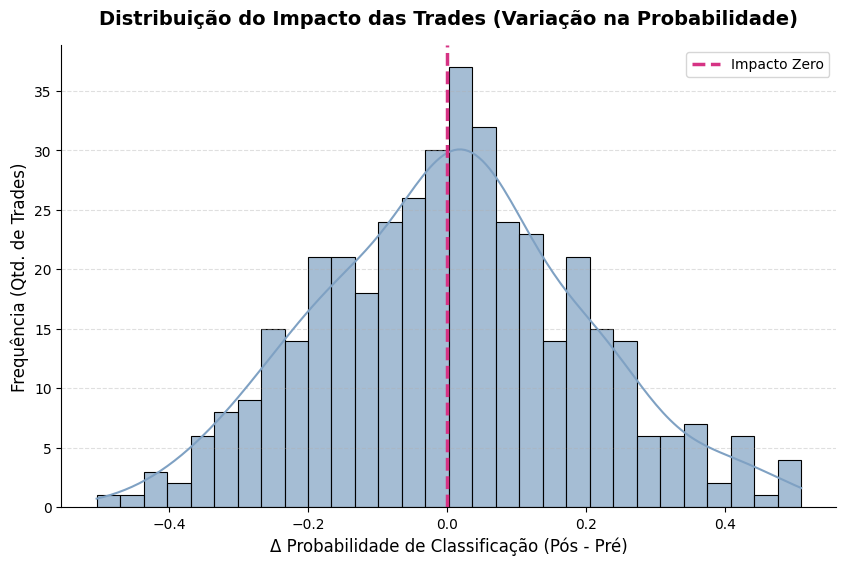

In [81]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_model, 
    x="delta_prob", 
    bins=30, 
    kde=True, 
    color="#7FA1C3",
    edgecolor="black",
    linewidth=0.8,
    alpha=0.7
)

plt.axvline(0, color="#D63384", linestyle="--", linewidth=2.5, label="Impacto Zero")

plt.title("Distribuição do Impacto das Trades (Variação na Probabilidade)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Δ Probabilidade de Classificação (Pós - Pré)", fontsize=12)
plt.ylabel("Frequência (Qtd. de Trades)", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend()

sns.despine()

plt.show()

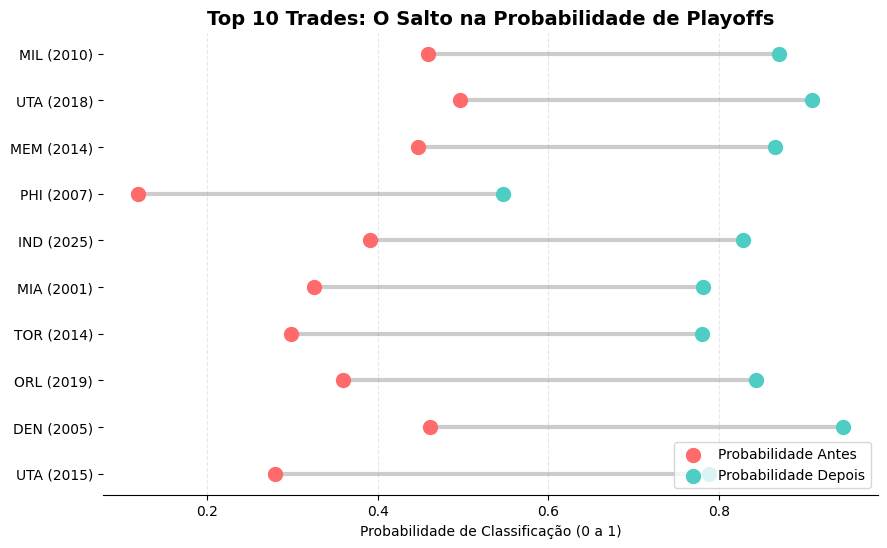

In [82]:
top_10 = df_model.sort_values("delta_prob", ascending=False).head(10).copy()

top_10["Label"] = top_10["team"] + " (" + top_10["season"].astype(str) + ")"

plt.figure(figsize=(10, 6))

plt.hlines(
    y=top_10["Label"], 
    xmin=top_10["prob_pre"], 
    xmax=top_10["prob_post"], 
    color='grey', 
    alpha=0.4, 
    linewidth=3
)

plt.scatter(
    top_10["prob_pre"], 
    top_10["Label"], 
    color='#FF6B6B', 
    s=100, 
    label='Probabilidade Antes',
    zorder=3 
)

plt.scatter(
    top_10["prob_post"], 
    top_10["Label"], 
    color='#4ECDC4', 
    s=100, 
    label='Probabilidade Depois',
    zorder=3
)

plt.title("Top 10 Trades: O Salto na Probabilidade de Playoffs", fontsize=14, fontweight="bold")
plt.xlabel("Probabilidade de Classificação (0 a 1)")
plt.legend(loc="lower right")
plt.grid(axis='x', linestyle='--', alpha=0.3)
sns.despine(left=True)

plt.show()

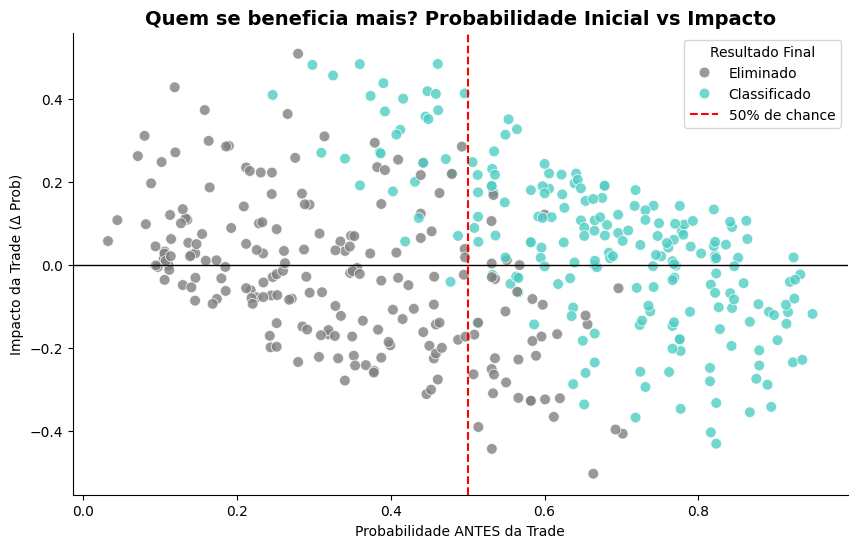

In [83]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_model, 
    x="prob_pre", 
    y="delta_prob", 
    hue="Playoff",
    palette={0: "gray", 1: "#4ECDC4"},
    alpha=0.8,
    s=60,
    edgecolor="w"
)

plt.axhline(0, color="black", linestyle="-", linewidth=1) 
plt.axvline(0.5, color="red", linestyle="--", linewidth=1.5, label="50% de chance")

plt.title("Quem se beneficia mais? Probabilidade Inicial vs Impacto", fontsize=14, fontweight="bold")
plt.xlabel("Probabilidade ANTES da Trade")
plt.ylabel("Impacto da Trade (Δ Prob)")

handles, labels = plt.gca().get_legend_handles_labels()

new_labels = ['Eliminado' if l == '0' else 'Classificado' if l == '1' else l for l in labels]

plt.legend(handles=handles, labels=new_labels, title="Resultado Final")

sns.despine()
plt.show()

In [84]:
accuracy = model.score(X_pre, y)
print(accuracy)

0.829683698296837


### 6.6 Conclusão

A modelagem probabilística permite quantificar diretamente o efeito das trades na probabilidade de classificação aos playoffs, indo além da simples análise de vitórias e capturando o impacto real das mudanças de elenco no desempenho das equipes.

Embora o impacto médio seja modesto, existem casos em que trades bem ajustadas promovem saltos significativos na probabilidade de sucesso, evidenciando seu papel estratégico como intervenções pontuais capazes de alterar o destino de uma temporada.

A mesma abordagem pode ser estendida para fases finais, permitindo estimar o impacto das trades na progressão em playoffs e na conquista do título.

## 7. Conclusão

Este trabalho investigou os principais fatores que explicam o sucesso na NBA sob uma perspectiva multidimensional, analisando consistência ao longo da temporada, perfis de jogadores, características estatísticas das equipes e o impacto de trades no desempenho.

Os resultados indicam que a consistência ao longo da temporada é um dos principais determinantes para alcançar os playoffs, com equipes que mantêm desempenho estável apresentando maior probabilidade de sucesso do que aquelas que dependem de evolução tardia ou picos de performance. Em paralelo, a análise de perfis de jogadores mostra que o basquete moderno é guiado por funções e habilidades específicas, com destaque para especialistas de perímetro e o espaçamento de quadra, reforçando que o encaixe tático é mais relevante do que posições tradicionais.

A avaliação do impacto dos jogadores e das estatísticas das equipes evidencia que o sucesso está fortemente ligado à qualidade e ao equilíbrio dos perfis presentes no elenco. Times mais competitivos tendem a apresentar maior eficiência ofensiva e uma composição mais funcional, evitando redundâncias e priorizando habilidades complementares.

No que diz respeito às trades, os resultados mostram que, em média, seu impacto é limitado, mas altamente variável. Em contextos específicos, como equipes próximas da zona de classificação, essas movimentações podem gerar mudanças significativas, funcionando como intervenções estratégicas capazes de alterar o rumo da temporada.

Por fim, a modelagem probabilística permitiu quantificar esse impacto de forma mais precisa, evidenciando que trades podem influenciar diretamente a probabilidade de classificação e, em casos específicos, a progressão em fases mais avançadas. Ainda assim, seu efeito deve ser interpretado como complementar, reforçando a importância de uma construção de elenco sólida e consistente ao longo de toda a temporada.